# Creating Numbers/images with AI: A Hands-on Diffusion Model Exercise

## Introduction
In this assignment, you'll learn how to create an AI model that can generate realistic images from scratch using a powerful technique called 'diffusion'. Think of it like teaching AI to draw by first learning how images get blurry and then learning to make them clear again.

### What We'll Build
- A diffusion model capable of generating realistic images
- For most students: An AI that generates handwritten digits (0-9) using the MNIST dataset
- For students with more computational resources: Options to work with more complex datasets
- Visual demonstrations of how random noise gradually transforms into clear, recognizable images
- By the end, your AI should create images realistic enough for another AI to recognize them

### Dataset Options
This lab offers flexibility based on your available computational resources:

- Standard Option (Free Colab): We'll primarily use the MNIST handwritten digit dataset, which works well with limited GPU memory and completes training in a reasonable time frame. Most examples and code in this notebook are optimized for MNIST.

- Advanced Option: If you have access to more powerful GPUs (either through Colab Pro/Pro+ or your own hardware), you can experiment with more complex datasets like Fashion-MNIST, CIFAR-10, or even face generation. You'll need to adapt the model architecture, hyperparameters, and evaluation metrics accordingly.

### Resource Requirements
- Basic MNIST: Works with free Colab GPUs (2-4GB VRAM), ~30 minutes training
- Fashion-MNIST: Similar requirements to MNIST
CIFAR-10: Requires more memory (8-12GB VRAM) and longer training (~2 hours)
- Higher resolution images: Requires substantial GPU resources and several hours of training

### Before You Start
1. Make sure you're running this in Google Colab or another environment with GPU access
2. Go to 'Runtime' → 'Change runtime type' and select 'GPU' as your hardware accelerator
3. Each code cell has comments explaining what it does
4. Don't worry if you don't understand every detail - focus on the big picture!
5. If working with larger datasets, monitor your GPU memory usage carefully

The concepts you learn with MNIST will scale to more complex datasets, so even if you're using the basic option, you'll gain valuable knowledge about generative AI that applies to more advanced applications.



## Step 1: Setting Up Our Tools
First, let's install and import all the tools we need. Run this cell and wait for it to complete.

In [ ]:
# Step 1: Install required packages
%pip install einops
print("Package installation complete.")

# Step 2: Import libraries
# --- Core PyTorch libraries ---
import torch  # Main deep learning framework
import torch.nn.functional as F  # Neural network functions like activation functions
import torch.nn as nn  # Neural network building blocks (layers)
from torch.optim import Adam  # Optimization algorithm for training

# --- Data handling ---
from torch.utils.data import Dataset, DataLoader  # For organizing and loading our data
import torchvision  # Library for computer vision datasets and models
import torchvision.transforms as transforms  # For preprocessing images

# --- Tensor manipulation ---
import random  # For random operations
from einops.layers.torch import Rearrange  # For reshaping tensors in neural networks
from einops import rearrange  # For elegant tensor reshaping operations
import numpy as np  # For numerical operations on arrays

# --- System utilities ---
import os  # For operating system interactions (used for CPU count)

# --- Visualization tools ---
import matplotlib.pyplot as plt  # For plotting images and graphs
from PIL import Image  # For image processing
from torchvision.utils import save_image, make_grid  # For saving and displaying image grids

# Step 3: Set up device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We'll be using: {device}")

# Check if we're actually using GPU (for students to verify)
if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Note: Training will be much slower on CPU. Consider using Google Colab with GPU enabled.")

Package installation complete.
We'll be using: cuda
GPU name: Tesla T4
GPU memory: 15.64 GB



###  REPRODUCIBILITY AND DEVICE SETUP

In [ ]:
# Step 4: Set random seeds for reproducibility
# Diffusion models are sensitive to initialization, so reproducible results help with debugging
SEED = 42  # Universal seed value for reproducibility
torch.manual_seed(SEED)          # PyTorch random number generator
np.random.seed(SEED)             # NumPy random number generator
random.seed(SEED)                # Python's built-in random number generator

print(f"Random seeds set to {SEED} for reproducible results")

# Configure CUDA for GPU operations if available
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)       # GPU random number generator
    torch.cuda.manual_seed_all(SEED)   # All GPUs random number generator

    # Ensure deterministic GPU operations
    # Note: This slightly reduces performance but ensures results are reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        # Check available GPU memory
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9  # Convert to GB
        print(f"Available GPU Memory: {gpu_memory:.1f} GB")

        # Add recommendation based on memory
        if gpu_memory < 4:
            print("Warning: Low GPU memory. Consider reducing batch size if you encounter OOM errors.")
    except Exception as e:
        print(f"Could not check GPU memory: {e}")
else:
    print("No GPU detected. Training will be much slower on CPU.")
    print("If you're using Colab, go to Runtime > Change runtime type and select GPU.")

Random seeds set to 42 for reproducible results
Available GPU Memory: 15.6 GB


## Step 2: Choosing Your Dataset

You have several options for this exercise, depending on your computer's capabilities:

### Option 1: MNIST (Basic - Works on Free Colab)
- Content: Handwritten digits (0-9)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You're using free Colab or have a basic GPU

### Option 2: Fashion-MNIST (Intermediate)
- Content: Clothing items (shirts, shoes, etc.)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You want more interesting images but have limited GPU

### Option 3: CIFAR-10 (Advanced)
- Content: Real-world objects (cars, animals, etc.)
- Image size: 32x32 pixels, Color (RGB)
- Training samples: 50,000
- Memory needed: ~4GB GPU
- Training time: ~1-2 hours on Colab
- **Choose this if**: You have Colab Pro or a good local GPU (8GB+ memory)

### Option 4: CelebA (Expert)
- Content: Celebrity face images
- Image size: 64x64 pixels, Color (RGB)
- Training samples: 200,000
- Memory needed: ~8GB GPU
- Training time: ~3-4 hours on Colab
- **Choose this if**: You have excellent GPU (12GB+ memory)

To use your chosen dataset, uncomment its section in the code below and make sure all others are commented out.

In [ ]:
#===============================================================================
# SECTION 2: DATASET SELECTION AND CONFIGURATION
#===============================================================================
# STUDENT INSTRUCTIONS:
# 1. Choose ONE dataset option based on your available GPU memory
# 2. Uncomment ONLY ONE dataset section below
# 3. Make sure all other dataset sections remain commented out

#-------------------------------------------
# OPTION 1: MNIST (Basic - 2GB GPU)
#-------------------------------------------
# Recommended for: Free Colab or basic GPU
# Memory needed: ~2GB GPU
# Training time: ~15-30 minutes

IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Your code to load the MNIST dataset
# Hint: Use torchvision.datasets.MNIST with root='./data', train=True,
#       transform=transform, and download=True
# Then print a success message

# Enter your code here:
dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
print("Success: MNIST dataset has been loaded!")

#-------------------------------------------
# OPTION 2: Fashion-MNIST (Intermediate - 2GB GPU)
#-------------------------------------------
# Uncomment this section to use Fashion-MNIST instead
"""
IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Your code to load the Fashion-MNIST dataset
# Hint: Very similar to MNIST but use torchvision.datasets.FashionMNIST

# Enter your code here:

"""

#-------------------------------------------
# OPTION 3: CIFAR-10 (Advanced - 4GB+ GPU)
#-------------------------------------------
# Uncomment this section to use CIFAR-10 instead
"""
IMG_SIZE = 32
IMG_CH = 3
N_CLASSES = 10
BATCH_SIZE = 32  # Reduced batch size for memory
EPOCHS = 50      # More epochs for complex data

# Your code to create the transform and load CIFAR-10
# Hint: Use transforms.Normalize with RGB means and stds ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# Then load torchvision.datasets.CIFAR10

# Enter your code here:

"""


Success: MNIST dataset has been loaded!


'\nIMG_SIZE = 32\nIMG_CH = 3\nN_CLASSES = 10\nBATCH_SIZE = 32  # Reduced batch size for memory\nEPOCHS = 50      # More epochs for complex data\n\n# Your code to create the transform and load CIFAR-10\n# Hint: Use transforms.Normalize with RGB means and stds ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))\n# Then load torchvision.datasets.CIFAR10\n\n# Enter your code here:\n\n'

In [ ]:
# Validating Dataset Selection
# Let's add code to validate that a dataset was selected
# and check if your GPU has enough memory:

# Validate dataset selection
if 'dataset' not in locals() and 'dataset' not in globals():
    raise ValueError("""
    ❌ ERROR: No dataset selected! Please uncomment exactly one dataset option in the previous cell and run it.
    Available options:
    1. MNIST (Basic) - 2GB GPU
    2. Fashion-MNIST (Intermediate) - 2GB GPU
    3. CIFAR-10 (Advanced) - 4GB+ GPU
    4. CelebA (Expert) - 8GB+ GPU
    """)
else:
    print("✓ Dataset selected successfully!")

# Your code to validate GPU memory requirements
if torch.cuda.is_available():
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"Available GPU memory: {gpu_mem_gb:.2f} GB")
    if gpu_mem_gb < 2.0:
        print("Warning: GPU memory is less than 2GB. You may encounter Out Of Memory (OOM) errors.")
    else:
        print("GPU memory is sufficient for the selected dataset.")
else:
    print("Warning: No GPU detected. Training will rely on the CPU and will be significantly slower.")


✓ Dataset selected successfully!
Available GPU memory: 14.56 GB
GPU memory is sufficient for the selected dataset.


In [ ]:
#Dataset Properties and Data Loaders
#Now let's examine our dataset
#and set up the data loaders:

# Your code to check sample batch properties
# Hint: Get a sample batch using next(iter(DataLoader(dataset, batch_size=1)))
# Then print information about the dataset shape, type, and value ranges

sample_batch = next(iter(DataLoader(dataset, batch_size=1)))
print(f"Image shape: {sample_batch[0].shape}")
print(f"Data type: {sample_batch[0].dtype}")
print(f"Min value: {sample_batch[0].min():.4f}, Max value: {sample_batch[0].max():.4f}")
print(f"Label shape: {sample_batch[1].shape}, Label value: {sample_batch[1].item()}")

#===============================================================================
# SECTION 3: DATASET SPLITTING AND DATALOADER CONFIGURATION
#===============================================================================
# Create train-validation split

# Your code to create a train-validation split (80% train, 20% validation)
# Hint: Use random_split() with appropriate train_size and val_size
# Be sure to use a fixed generator for reproducibility

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size], generator=generator)
print(f"\nDataset split: {len(train_dataset)} training samples, {len(val_dataset)} validation samples")

# Your code to create dataloaders for training and validation
# Hint: Use DataLoader with batch_size=BATCH_SIZE, appropriate shuffle settings,
# and num_workers based on available CPU cores

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=min(2, os.cpu_count() or 1))
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=min(2, os.cpu_count() or 1))
print(f"Created train_dataloader with {len(train_dataloader)} batches")
print(f"Created val_dataloader with {len(val_dataloader)} batches")

Image shape: torch.Size([1, 1, 28, 28])
Data type: torch.float32
Min value: -1.0000, Max value: 1.0000
Label shape: torch.Size([1]), Label value: 5

Dataset split: 48000 training samples, 12000 validation samples
Created train_dataloader with 750 batches
Created val_dataloader with 188 batches


## Step 3: Building Our Model Components

Now we'll create the building blocks of our AI model. Think of these like LEGO pieces that we'll put together to make our number generator:

- GELUConvBlock: The basic building block that processes images
- DownBlock: Makes images smaller while finding important features
- UpBlock: Makes images bigger again while keeping the important features
- Other blocks: Help the model understand time and what number to generate

In [ ]:
# Basic building block that processes images
class GELUConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, group_size):
        super().__init__()
        if out_ch % group_size != 0:
            group_size = min(group_size, out_ch)
            while out_ch % group_size != 0:
                group_size -= 1
        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(group_size, out_ch),
            nn.GELU()
        )
    def forward(self, x):
        return self.model(x)


In [ ]:
# Rearranges pixels to downsample the image (2x reduction in spatial dimensions)
class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs, group_size):
        super().__init__()
        self.model = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2),
            GELUConvBlock(in_chs * 4, in_chs, group_size)
        )
    def forward(self, x):
        return self.model(x)


In [ ]:
#Let's implement the upsampling block for our U-Net architecture:
class DownBlock(nn.Module):
    """
    Downsampling block for encoding path in U-Net architecture.

    This block:
    1. Processes input features with two convolutional blocks
    2. Downsamples spatial dimensions by 2x using pixel rearrangement

    Args:
        in_chs (int): Number of input channels
        out_chs (int): Number of output channels
        group_size (int): Number of groups for GroupNorm
    """
    def __init__(self, in_chs, out_chs, group_size):
        super().__init__()  # Simplified super() call, equivalent to original

        # Sequential processing of features
        layers = [
            GELUConvBlock(in_chs, out_chs, group_size),  # First conv block changes channel dimensions
            GELUConvBlock(out_chs, out_chs, group_size),  # Second conv block processes features
            RearrangePoolBlock(out_chs, group_size)       # Downsampling (spatial dims: H,W → H/2,W/2)
        ]
        self.model = nn.Sequential(*layers)

        # Log the configuration for debugging
        print(f"Created DownBlock: in_chs={in_chs}, out_chs={out_chs}, spatial_reduction=2x")

    def forward(self, x):
        """
        Forward pass through the DownBlock.

        Args:
            x (torch.Tensor): Input tensor of shape [B, in_chs, H, W]

        Returns:
            torch.Tensor: Output tensor of shape [B, out_chs, H/2, W/2]
        """
        return self.model(x)

In [ ]:
class UpBlock(nn.Module):
    def __init__(self, in_chs, out_chs, group_size):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_chs, in_chs, kernel_size=2, stride=2)
        self.convs = nn.Sequential(
            GELUConvBlock(in_chs + out_chs, out_chs, group_size),  # FIX: in_chs + out_chs instead of in_chs * 2
            GELUConvBlock(out_chs, out_chs, group_size)
        )
    def forward(self, x, skip):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)
        return self.convs(x)


In [ ]:
# Here we implement the time embedding block for our U-Net architecture:
# Helps the model understand time steps in diffusion process
class SinusoidalPositionEmbedBlock(nn.Module):
    """
    Creates sinusoidal embeddings for time steps in diffusion process.

    This embedding scheme is adapted from the Transformer architecture and
    provides a unique representation for each time step that preserves
    relative distance information.

    Args:
        dim (int): Embedding dimension
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        """
        Computes sinusoidal embeddings for given time steps.

        Args:
            time (torch.Tensor): Time steps tensor of shape [batch_size]

        Returns:
            torch.Tensor: Time embeddings of shape [batch_size, dim]
        """
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings



In [ ]:
class EmbedBlock(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super(EmbedBlock, self).__init__()
        self.input_dim = input_dim
        self.model = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1))
        )
    def forward(self, x):
        x = x.view(-1, self.input_dim)
        return self.model(x)


In [ ]:
class UNet(nn.Module):
    def __init__(self, T, img_ch, img_size, down_chs, t_embed_dim, c_embed_dim):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbedBlock(t_embed_dim),
            nn.Linear(t_embed_dim, t_embed_dim),
            nn.GELU()
        )
        self.class_embed = EmbedBlock(c_embed_dim, t_embed_dim)
        self.init_conv = GELUConvBlock(img_ch, down_chs[0], group_size=8)
        self.down_blocks = nn.ModuleList([
            DownBlock(down_chs[i], down_chs[i+1], group_size=8) for i in range(len(down_chs)-1)
        ])
        self.mid_block = nn.Sequential(
            GELUConvBlock(down_chs[-1], down_chs[-1], group_size=8),
            GELUConvBlock(down_chs[-1], down_chs[-1], group_size=8)
        )
        self.up_blocks = nn.ModuleList([
            UpBlock(down_chs[i], down_chs[i-1], group_size=8) for i in range(len(down_chs)-1, 0, -1)
        ])
        self.out_conv = nn.Conv2d(down_chs[0], img_ch, kernel_size=3, padding=1)
    def forward(self, x, t, c, c_mask):
        t_emb = self.time_embed(t).unsqueeze(-1).unsqueeze(-1)
        c_emb = self.class_embed(c) * c_mask.unsqueeze(-1).unsqueeze(-1)
        emb = t_emb + c_emb
        x1 = self.init_conv(x)
        skips = [x1]
        for block in self.down_blocks:
            x_down = block(skips[-1])
            skips.append(x_down)
        x_mid = self.mid_block(skips.pop() + emb)
        for block in self.up_blocks:
            x_mid = block(x_mid, skips.pop())
        return self.out_conv(x_mid)


## Step 4: Setting Up The Diffusion Process

Now we'll create the process of adding and removing noise from images. Think of it like:
1. Adding fog: Slowly making the image more and more blurry until you can't see it
2. Removing fog: Teaching the AI to gradually make the image clearer
3. Controlling the process: Making sure we can generate specific numbers we want

In [ ]:
# Set up the noise schedule
n_steps = 100  # How many steps to go from clear image to noise
beta_start = 0.0001  # Starting noise level (small)
beta_end = 0.02      # Ending noise level (larger)

# Create schedule of gradually increasing noise levels
beta = torch.linspace(beta_start, beta_end, n_steps).to(device)

# Calculate important values used in diffusion equations
alpha = 1 - beta  # Portion of original image to keep at each step
alpha_bar = torch.cumprod(alpha, dim=0)  # Cumulative product of alphas
sqrt_alpha_bar = torch.sqrt(alpha_bar)  # For scaling the original image
sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar)  # For scaling the noise


In [ ]:

# Function to add noise to images (forward diffusion process)
def add_noise(x_0, t):
    """
    Add noise to images according to the forward diffusion process.

    The formula is: x_t = √(α_bar_t) * x_0 + √(1-α_bar_t) * ε
    where ε is random noise and α_bar_t is the cumulative product of (1-β).

    Args:
        x_0 (torch.Tensor): Original clean image [B, C, H, W]
        t (torch.Tensor): Timestep indices indicating noise level [B]

    Returns:
        tuple: (noisy_image, noise_added)
            - noisy_image is the image with noise added
            - noise_added is the actual noise that was added (for training)
    """
    # Create random Gaussian noise with same shape as image
    noise = torch.randn_like(x_0)

    # Get noise schedule values for the specified timesteps
    # Reshape to allow broadcasting with image dimensions
    sqrt_alpha_bar_t = sqrt_alpha_bar[t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar[t].reshape(-1, 1, 1, 1)

    # Apply the forward diffusion equation:
    # Mixture of original image (scaled down) and noise (scaled up)
    x_t = sqrt_alpha_bar_t * x_0 + sqrt_one_minus_alpha_bar_t * noise

    return x_t, noise


In [ ]:
# Function to remove noise from images (reverse diffusion process)
@torch.no_grad()  # Don't track gradients during sampling (inference only)
def remove_noise(x_t, t, model, c, c_mask):
    """
    Remove noise from images using the learned reverse diffusion process.

    This implements a single step of the reverse diffusion sampling process.
    The model predicts the noise in the image, which we then use to partially
    denoise the image.

    Args:
        x_t (torch.Tensor): Noisy image at timestep t [B, C, H, W]
        t (torch.Tensor): Current timestep indices [B]
        model (nn.Module): U-Net model that predicts noise
        c (torch.Tensor): Class conditioning (what digit to generate) [B, C]
        c_mask (torch.Tensor): Mask for conditional generation [B, 1]

    Returns:
        torch.Tensor: Less noisy image for the next timestep [B, C, H, W]
    """
    # Predict the noise in the image using our model
    predicted_noise = model(x_t, t, c, c_mask)

    # Get noise schedule values for the current timestep
    alpha_t = alpha[t].reshape(-1, 1, 1, 1)
    alpha_bar_t = alpha_bar[t].reshape(-1, 1, 1, 1)
    beta_t = beta[t].reshape(-1, 1, 1, 1)

    # FIX: Calculate the missing variable
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1 - alpha_bar_t)

    # Special case: if we're at the first timestep (t=0), we're done
    if t[0] == 0:
        return x_t
    else:
        # Calculate the mean of the denoised distribution
        # This is derived from Bayes' rule and the diffusion process equations
        mean = (1 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise
        )

        # Add a small amount of random noise (variance depends on timestep)
        # This helps prevent the generation from becoming too deterministic
        noise = torch.randn_like(x_t)

        # Return the partially denoised image with a bit of new random noise
        return mean + torch.sqrt(beta_t) * noise

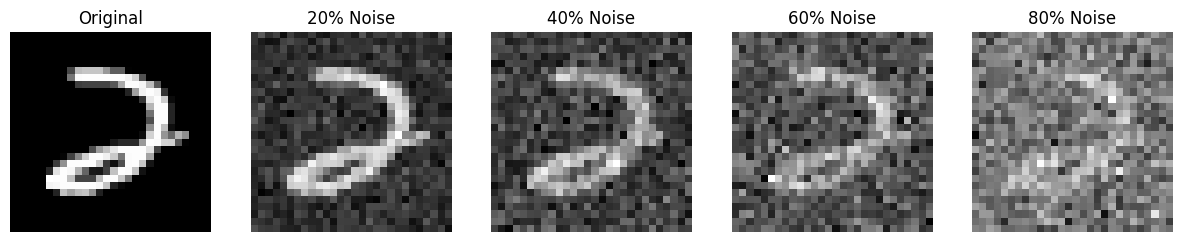

'\n# Try a non-linear noise schedule\nbeta_alt = torch.linspace(beta_start, beta_end, n_steps)**2\nalpha_alt = 1 - beta_alt\nalpha_bar_alt = torch.cumprod(alpha_alt, dim=0)\n# How would this affect the diffusion process?\n'

In [ ]:
# Visualization function to show how noise progressively affects images
def show_noise_progression(image, num_steps=5):
    """
    Visualize how an image gets progressively noisier in the diffusion process.

    Args:
        image (torch.Tensor): Original clean image [C, H, W]
        num_steps (int): Number of noise levels to show
    """
    plt.figure(figsize=(15, 3))

    # Show original image
    plt.subplot(1, num_steps, 1)
    if IMG_CH == 1:  # Grayscale image
        plt.imshow(image[0].cpu(), cmap='gray')
    else:  # Color image
        img = image.permute(1, 2, 0).cpu()  # Change from [C,H,W] to [H,W,C]
        if img.min() < 0:  # If normalized between -1 and 1
            img = (img + 1) / 2  # Rescale to [0,1] for display
        plt.imshow(img)
    plt.title('Original')
    plt.axis('off')

    # Show progressively noisier versions
    for i in range(1, num_steps):
        # Calculate timestep index based on percentage through the process
        t_idx = int((i/num_steps) * n_steps)
        t = torch.tensor([t_idx]).to(device)

        # Add noise corresponding to timestep t
        noisy_image, _ = add_noise(image.unsqueeze(0), t)

        # Display the noisy image
        plt.subplot(1, num_steps, i+1)
        if IMG_CH == 1:
            plt.imshow(noisy_image[0][0].cpu(), cmap='gray')
        else:
            img = noisy_image[0].permute(1, 2, 0).cpu()
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)
        plt.title(f'{int((i/num_steps) * 100)}% Noise')
        plt.axis('off')
    plt.show()

# Show an example of noise progression on a real image
sample_batch = next(iter(train_dataloader))  # Get first batch
sample_image = sample_batch[0][0].to(device)  # Get first image
show_noise_progression(sample_image)

# Student Activity: Try different noise schedules
# Uncomment and modify these lines to experiment:
"""
# Try a non-linear noise schedule
beta_alt = torch.linspace(beta_start, beta_end, n_steps)**2
alpha_alt = 1 - beta_alt
alpha_bar_alt = torch.cumprod(alpha_alt, dim=0)
# How would this affect the diffusion process?
"""

## Step 5: Training Our Model

Now we'll teach our AI to generate images. This process:
1. Takes a clear image
2. Adds random noise to it
3. Asks our AI to predict what noise was added
4. Helps our AI learn from its mistakes

This will take a while, but we'll see progress as it learns!

In [ ]:
# Create our model and move it to GPU if available
model = UNet(
    T=n_steps,                 # Number of diffusion time steps
    img_ch=IMG_CH,             # Number of channels in our images (1 for grayscale, 3 for RGB)
    img_size=IMG_SIZE,         # Size of input images (28 for MNIST, 32 for CIFAR-10)
    down_chs=(32, 64, 128),    # Channel dimensions for each downsampling level
    t_embed_dim=128,           # FIX: Dimension for time step embeddings MUST match bottleneck (128)
    c_embed_dim=N_CLASSES      # Number of classes for conditioning
).to(device)

# Print model summary
print(f"\n{'='*50}")
print(f"MODEL ARCHITECTURE SUMMARY")
print(f"{'='*50}")
print(f"Input resolution: {IMG_SIZE}x{IMG_SIZE}")
print(f"Input channels: {IMG_CH}")
print(f"Time steps: {n_steps}")
print(f"Condition classes: {N_CLASSES}")
print(f"GPU acceleration: {'Yes' if device.type == 'cuda' else 'No'}")

# Validate model parameters and estimate memory requirements
# We will define the function validate_model_parameters in the next cell
try:
    validate_model_parameters(model)
except NameError:
    print("validate_model_parameters function will be defined in the next cell.")

# Your code to verify data ranges and integrity
try:
    verify_data_range(train_dataloader, "Training Data")
    verify_data_range(val_dataloader, "Validation Data")
except NameError:
    print("verify_data_range function will be defined in the next cell.")

# Set up the optimizer with parameters tuned for diffusion models
# Note: Lower learning rates tend to work better for diffusion models
initial_lr = 0.001  # Starting learning rate
weight_decay = 1e-5  # L2 regularization to prevent overfitting

optimizer = Adam(
    model.parameters(),
    lr=initial_lr,
    weight_decay=weight_decay
)

# Learning rate scheduler to reduce LR when validation loss plateaus
# This helps fine-tune the model toward the end of training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',              # Reduce LR when monitored value stops decreasing
    factor=0.5,              # Multiply LR by this factor
    patience=5,              # Number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6              # Lower bound on the learning rate
)


Created DownBlock: in_chs=32, out_chs=64, spatial_reduction=2x
Created DownBlock: in_chs=64, out_chs=128, spatial_reduction=2x

MODEL ARCHITECTURE SUMMARY
Input resolution: 28x28
Input channels: 1
Time steps: 100
Condition classes: 10
GPU acceleration: Yes
Total parameters: 1,613,281
Trainable parameters: 1,613,281
Estimated GPU memory usage: 24.6 MB

Training Data range check:
Shape: torch.Size([64, 1, 28, 28])
Data type: torch.float32
Min value: -1.00
Max value: 1.00
Contains NaN: False
Contains Inf: False

Validation Data range check:
Shape: torch.Size([64, 1, 28, 28])
Data type: torch.float32
Min value: -1.00
Max value: 1.00
Contains NaN: False
Contains Inf: False


In [ ]:
# Define helper functions needed for training and evaluation
def validate_model_parameters(model):
    """
    Counts model parameters and estimates memory usage.
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Estimate memory requirements (very approximate)
    param_memory = total_params * 4 / (1024 ** 2)  # MB for params (float32)
    grad_memory = trainable_params * 4 / (1024 ** 2)  # MB for gradients
    buffer_memory = param_memory * 2  # Optimizer state, forward activations, etc.

    print(f"Estimated GPU memory usage: {param_memory + grad_memory + buffer_memory:.1f} MB")

# Define helper functions for verifying data ranges
def verify_data_range(dataloader, name="Dataset"):
    """
    Verifies the range and integrity of the data.
    """
    batch = next(iter(dataloader))[0]
    print(f"\n{name} range check:")
    print(f"Shape: {batch.shape}")
    print(f"Data type: {batch.dtype}")
    print(f"Min value: {batch.min().item():.2f}")
    print(f"Max value: {batch.max().item():.2f}")
    print(f"Contains NaN: {torch.isnan(batch).any().item()}")
    print(f"Contains Inf: {torch.isinf(batch).any().item()}")

# Define helper functions for generating samples during training
def generate_samples(model, n_samples=10):
    """
    Generates sample images using the model for visualization during training.
    """
    model.eval()
    with torch.no_grad():
        # Generate digits 0-9 for visualization
        samples = []
        for digit in range(min(n_samples, 10)):
            # Start with random noise
            x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

            # Set up conditioning for the digit
            c = torch.tensor([digit]).to(device)
            c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
            c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

            # Remove noise step by step
            for t in range(n_steps-1, -1, -1):
                t_batch = torch.full((1,), t).to(device)
                x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            samples.append(x)

        # Combine samples and display
        samples = torch.cat(samples, dim=0)
        grid = make_grid(samples, nrow=min(n_samples, 5), normalize=True)

        plt.figure(figsize=(10, 4))

        # Display based on channel configuration
        if IMG_CH == 1:
            plt.imshow(grid[0].cpu(), cmap='gray')
        else:
            plt.imshow(grid.permute(1, 2, 0).cpu())

        plt.axis('off')
        plt.title('Generated Samples')
        plt.show()

# Define helper functions for safely saving models
def safe_save_model(model, path, optimizer=None, epoch=None, best_loss=None):
    """
    Safely saves model with error handling and backup.
    """
    try:
        # Create a dictionary with all the elements to save
        save_dict = {
            'model_state_dict': model.state_dict(),
        }

        # Add optional elements if provided
        if optimizer is not None:
            save_dict['optimizer_state_dict'] = optimizer.state_dict()
        if epoch is not None:
            save_dict['epoch'] = epoch
        if best_loss is not None:
            save_dict['best_loss'] = best_loss

        # Create a backup of previous checkpoint if it exists
        if os.path.exists(path):
            backup_path = path + '.backup'
            try:
                os.replace(path, backup_path)
                print(f"Created backup at {backup_path}")
            except Exception as e:
                print(f"Warning: Could not create backup - {e}")

        # Save the new checkpoint
        torch.save(save_dict, path)
        print(f"Model successfully saved to {path}")

    except Exception as e:
        print(f"Error saving model: {e}")
        print("Attempting emergency save...")

        try:
            emergency_path = path + '.emergency'
            torch.save(model.state_dict(), emergency_path)
            print(f"Emergency save successful: {emergency_path}")
        except:
            print("Emergency save failed. Could not save model.")

In [ ]:
#  Implementation of the training step function
def train_step(x, c):
    """
    Performs a single training step for the diffusion model.

    This function:
    1. Prepares class conditioning
    2. Samples random timesteps for each image
    3. Adds corresponding noise to the images
    4. Asks the model to predict the noise
    5. Calculates the loss between predicted and actual noise

    Args:
        x (torch.Tensor): Batch of clean images [batch_size, channels, height, width]
        c (torch.Tensor): Batch of class labels [batch_size]

    Returns:
        torch.Tensor: Mean squared error loss value
    """
    # Convert number labels to one-hot encoding for class conditioning
    # Example: Label 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] for MNIST
    c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)

    # Create conditioning mask (all ones for standard training)
    # Added .float() for perfect type safety during multiplication
    c_mask = torch.ones_like(c.unsqueeze(-1)).float().to(device)

    # Pick random timesteps for each image in the batch
    # Different timesteps allow the model to learn the entire diffusion process
    t = torch.randint(0, n_steps, (x.shape[0],)).to(device)

    # Add noise to images according to the forward diffusion process
    # This simulates images at different stages of the diffusion process
    x_t, noise = add_noise(x, t)

    # The model tries to predict the exact noise that was added
    # This is the core learning objective of diffusion models
    predicted_noise = model(x_t, t, c_one_hot, c_mask)

    # Calculate loss: how accurately did the model predict the noise?
    # MSE loss works well for image-based diffusion models
    loss = F.mse_loss(predicted_noise, noise)

    return loss



STARTING TRAINING

Epoch 1/30
--------------------
  Step 0/750, Loss: 0.0819
  Step 100/750, Loss: 0.0801
  Step 200/750, Loss: 0.0740
  Step 300/750, Loss: 0.0690
  Step 400/750, Loss: 0.0782
  Step 500/750, Loss: 0.0706
  Generating samples...


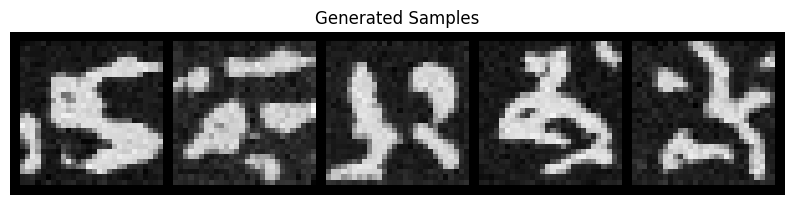

  Step 600/750, Loss: 0.0633
  Step 700/750, Loss: 0.0606

Training - Epoch 1 average loss: 0.0720
Running validation...
Validation - Epoch 1 average loss: 0.0679
Learning rate: 0.001000

Generating samples for visual progress check...


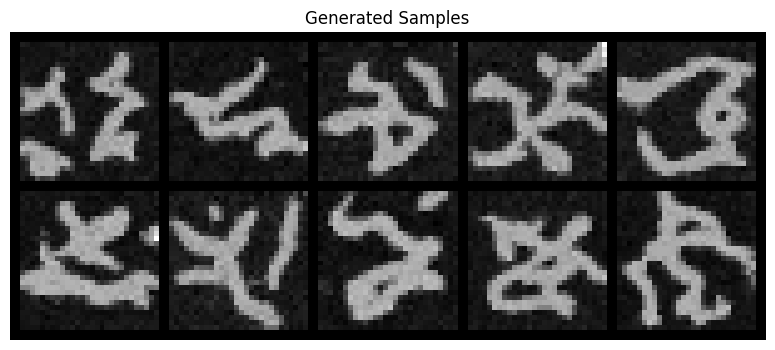

Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0679)


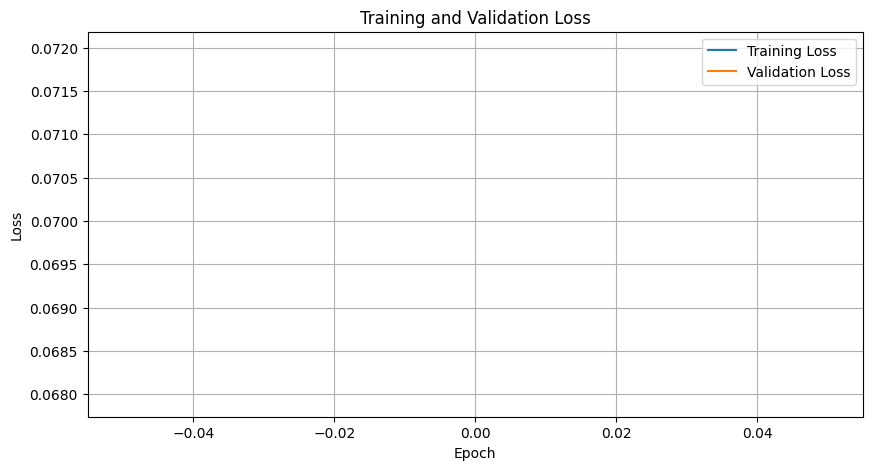


Epoch 2/30
--------------------
  Step 0/750, Loss: 0.0600
  Step 100/750, Loss: 0.0756
  Step 200/750, Loss: 0.0647
  Step 300/750, Loss: 0.0646
  Step 400/750, Loss: 0.0640
  Step 500/750, Loss: 0.0565
  Generating samples...


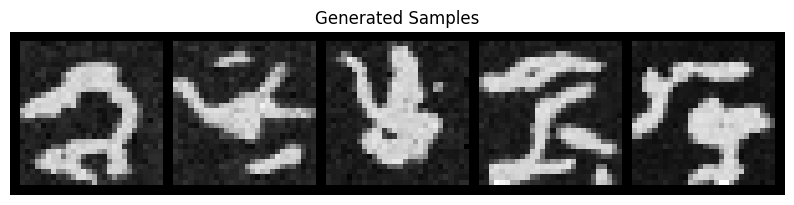

  Step 600/750, Loss: 0.0626
  Step 700/750, Loss: 0.0658

Training - Epoch 2 average loss: 0.0663
Running validation...
Validation - Epoch 2 average loss: 0.0645
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0645)

Epoch 3/30
--------------------
  Step 0/750, Loss: 0.0731
  Step 100/750, Loss: 0.0607
  Step 200/750, Loss: 0.0579
  Step 300/750, Loss: 0.0624
  Step 400/750, Loss: 0.0706
  Step 500/750, Loss: 0.0635
  Generating samples...


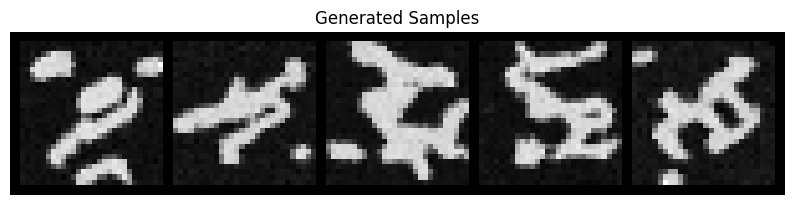

  Step 600/750, Loss: 0.0672
  Step 700/750, Loss: 0.0673

Training - Epoch 3 average loss: 0.0642
Running validation...
Validation - Epoch 3 average loss: 0.0633
Learning rate: 0.001000

Generating samples for visual progress check...


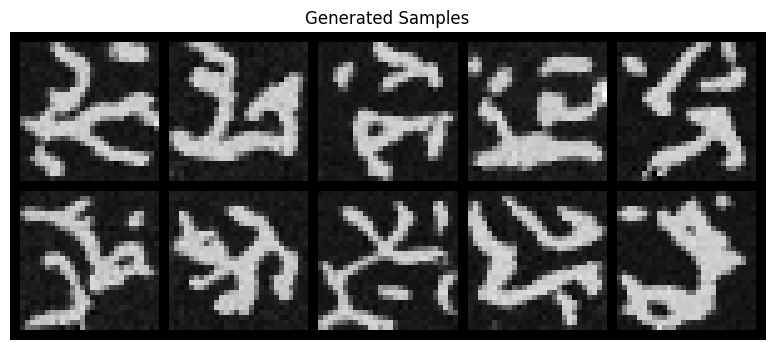

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0633)

Epoch 4/30
--------------------
  Step 0/750, Loss: 0.0600
  Step 100/750, Loss: 0.0577
  Step 200/750, Loss: 0.0607
  Step 300/750, Loss: 0.0581
  Step 400/750, Loss: 0.0572
  Step 500/750, Loss: 0.0651
  Generating samples...


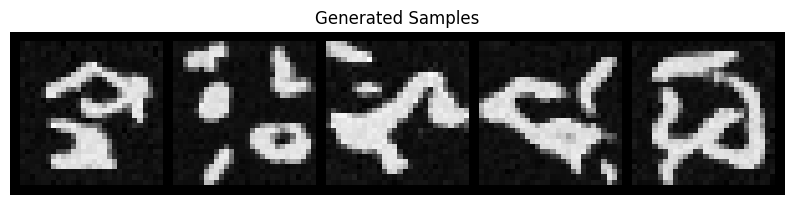

  Step 600/750, Loss: 0.0610
  Step 700/750, Loss: 0.0754

Training - Epoch 4 average loss: 0.0623
Running validation...
Validation - Epoch 4 average loss: 0.0622
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0622)

Epoch 5/30
--------------------
  Step 0/750, Loss: 0.0646
  Step 100/750, Loss: 0.0649
  Step 200/750, Loss: 0.0642
  Step 300/750, Loss: 0.0574
  Step 400/750, Loss: 0.0618
  Step 500/750, Loss: 0.0672
  Generating samples...


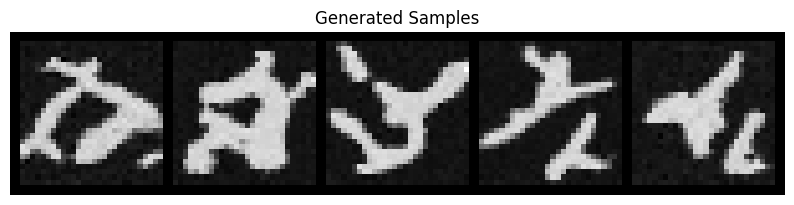

  Step 600/750, Loss: 0.0633
  Step 700/750, Loss: 0.0641

Training - Epoch 5 average loss: 0.0617
Running validation...
Validation - Epoch 5 average loss: 0.0620
Learning rate: 0.001000

Generating samples for visual progress check...


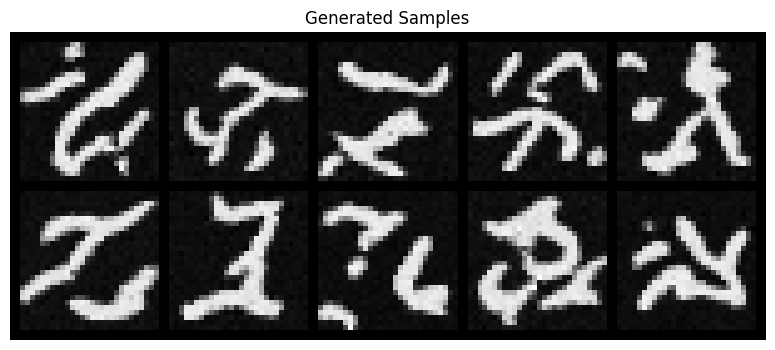

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0620)

Epoch 6/30
--------------------
  Step 0/750, Loss: 0.0674
  Step 100/750, Loss: 0.0603
  Step 200/750, Loss: 0.0551
  Step 300/750, Loss: 0.0642
  Step 400/750, Loss: 0.0548
  Step 500/750, Loss: 0.0584
  Generating samples...


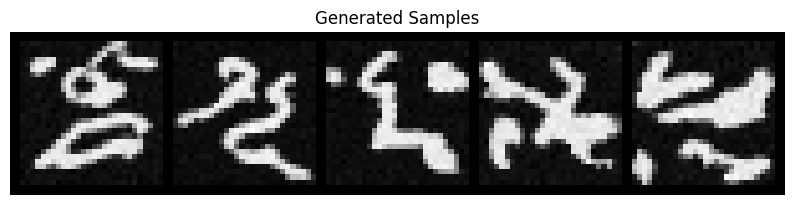

  Step 600/750, Loss: 0.0612
  Step 700/750, Loss: 0.0676

Training - Epoch 6 average loss: 0.0608
Running validation...
Validation - Epoch 6 average loss: 0.0617
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0617)


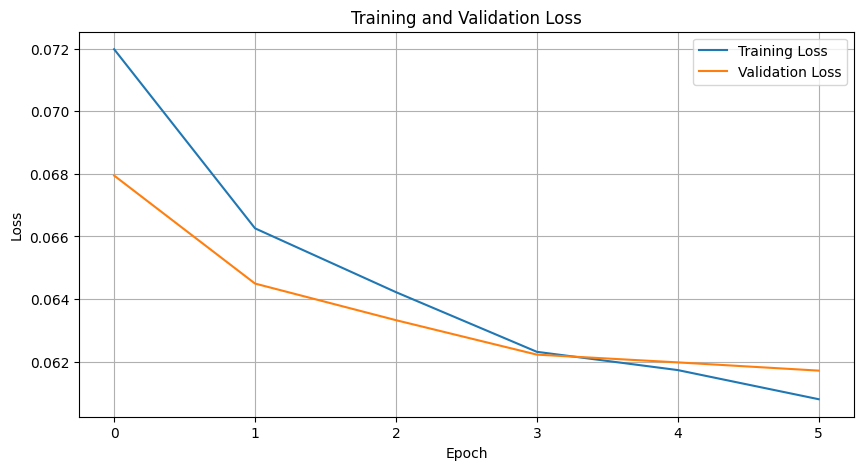


Epoch 7/30
--------------------
  Step 0/750, Loss: 0.0656
  Step 100/750, Loss: 0.0649
  Step 200/750, Loss: 0.0451
  Step 300/750, Loss: 0.0521
  Step 400/750, Loss: 0.0650
  Step 500/750, Loss: 0.0535
  Generating samples...


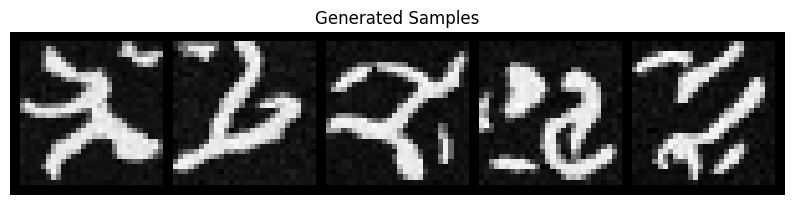

  Step 600/750, Loss: 0.0630
  Step 700/750, Loss: 0.0620

Training - Epoch 7 average loss: 0.0605
Running validation...
Validation - Epoch 7 average loss: 0.0598
Learning rate: 0.001000

Generating samples for visual progress check...


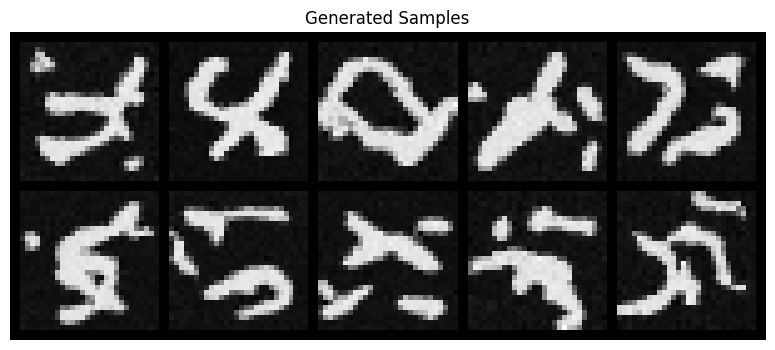

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0598)

Epoch 8/30
--------------------
  Step 0/750, Loss: 0.0583
  Step 100/750, Loss: 0.0667
  Step 200/750, Loss: 0.0548
  Step 300/750, Loss: 0.0600
  Step 400/750, Loss: 0.0647
  Step 500/750, Loss: 0.0525
  Generating samples...


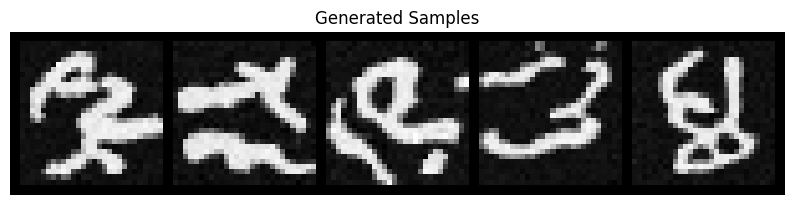

  Step 600/750, Loss: 0.0561
  Step 700/750, Loss: 0.0582

Training - Epoch 8 average loss: 0.0602
Running validation...
Validation - Epoch 8 average loss: 0.0590
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0590)

Epoch 9/30
--------------------
  Step 0/750, Loss: 0.0633
  Step 100/750, Loss: 0.0578
  Step 200/750, Loss: 0.0671
  Step 300/750, Loss: 0.0610
  Step 400/750, Loss: 0.0655
  Step 500/750, Loss: 0.0534
  Generating samples...


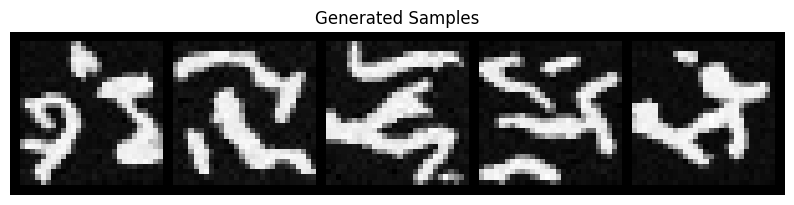

  Step 600/750, Loss: 0.0647
  Step 700/750, Loss: 0.0592

Training - Epoch 9 average loss: 0.0601
Running validation...
Validation - Epoch 9 average loss: 0.0615
Learning rate: 0.001000

Generating samples for visual progress check...


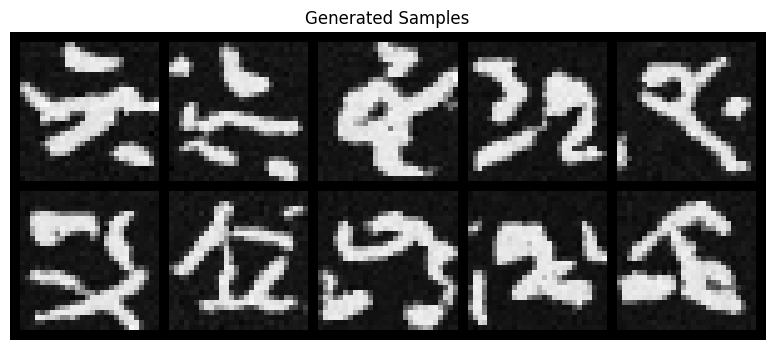

No improvement for 1/10 epochs

Epoch 10/30
--------------------
  Step 0/750, Loss: 0.0733
  Step 100/750, Loss: 0.0523
  Step 200/750, Loss: 0.0628
  Step 300/750, Loss: 0.0514
  Step 400/750, Loss: 0.0569
  Step 500/750, Loss: 0.0585
  Generating samples...


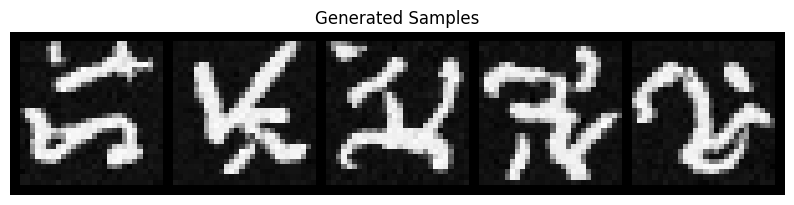

  Step 600/750, Loss: 0.0632
  Step 700/750, Loss: 0.0590

Training - Epoch 10 average loss: 0.0591
Running validation...
Validation - Epoch 10 average loss: 0.0606
Learning rate: 0.001000
No improvement for 2/10 epochs

Epoch 11/30
--------------------
  Step 0/750, Loss: 0.0605
  Step 100/750, Loss: 0.0591
  Step 200/750, Loss: 0.0637
  Step 300/750, Loss: 0.0610
  Step 400/750, Loss: 0.0586
  Step 500/750, Loss: 0.0620
  Generating samples...


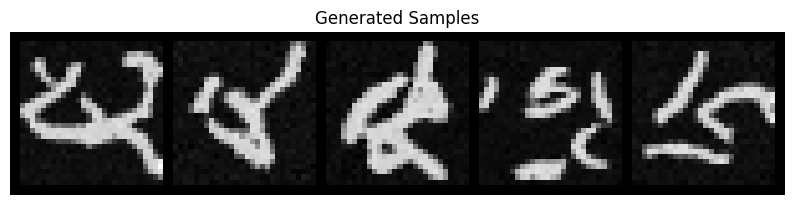

  Step 600/750, Loss: 0.0583
  Step 700/750, Loss: 0.0717

Training - Epoch 11 average loss: 0.0587
Running validation...
Validation - Epoch 11 average loss: 0.0588
Learning rate: 0.001000

Generating samples for visual progress check...


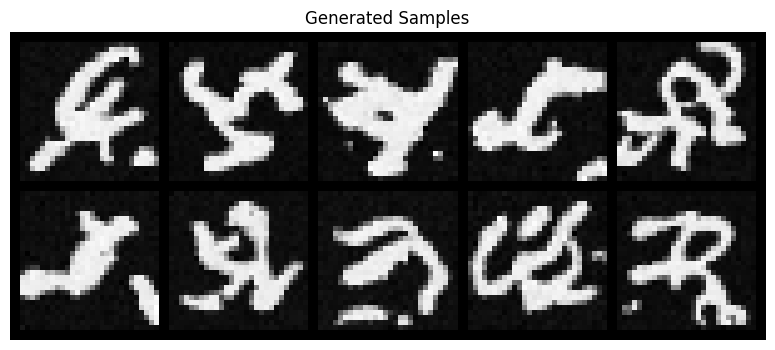

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0588)


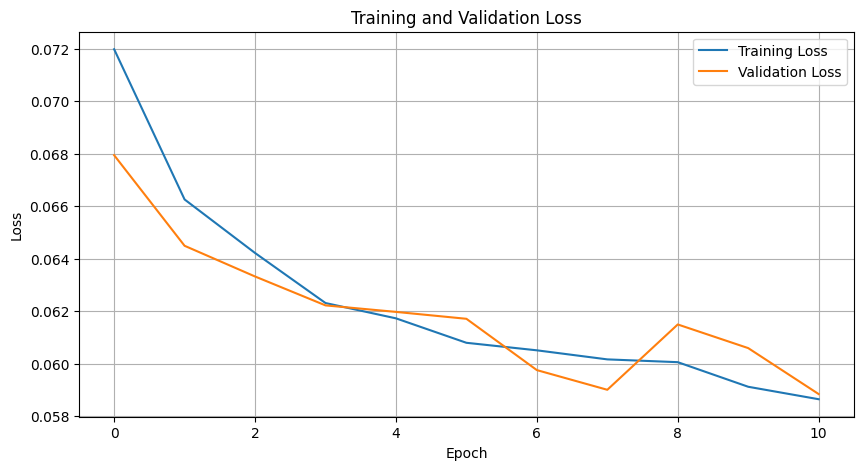


Epoch 12/30
--------------------
  Step 0/750, Loss: 0.0611
  Step 100/750, Loss: 0.0591
  Step 200/750, Loss: 0.0584
  Step 300/750, Loss: 0.0590
  Step 400/750, Loss: 0.0623
  Step 500/750, Loss: 0.0580
  Generating samples...


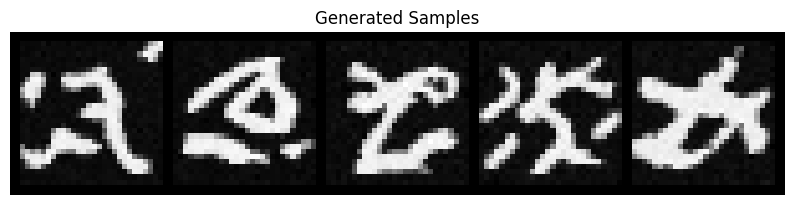

  Step 600/750, Loss: 0.0688
  Step 700/750, Loss: 0.0569

Training - Epoch 12 average loss: 0.0583
Running validation...
Validation - Epoch 12 average loss: 0.0587
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0587)

Epoch 13/30
--------------------
  Step 0/750, Loss: 0.0669
  Step 100/750, Loss: 0.0556
  Step 200/750, Loss: 0.0597
  Step 300/750, Loss: 0.0477
  Step 400/750, Loss: 0.0679
  Step 500/750, Loss: 0.0592
  Generating samples...


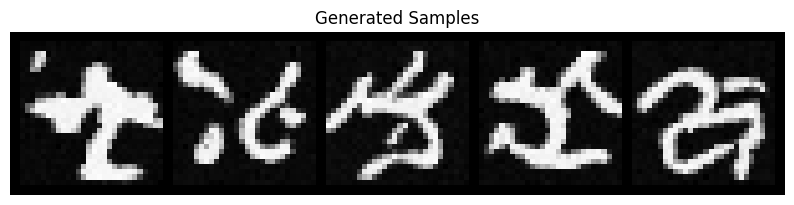

  Step 600/750, Loss: 0.0553
  Step 700/750, Loss: 0.0522

Training - Epoch 13 average loss: 0.0583
Running validation...
Validation - Epoch 13 average loss: 0.0582
Learning rate: 0.001000

Generating samples for visual progress check...


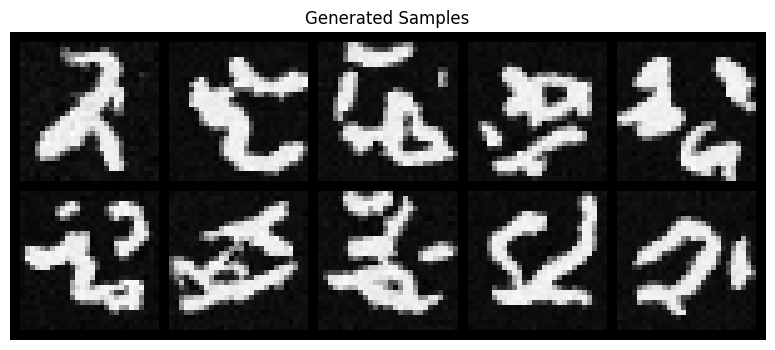

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0582)

Epoch 14/30
--------------------
  Step 0/750, Loss: 0.0674
  Step 100/750, Loss: 0.0601
  Step 200/750, Loss: 0.0607
  Step 300/750, Loss: 0.0494
  Step 400/750, Loss: 0.0532
  Step 500/750, Loss: 0.0634
  Generating samples...


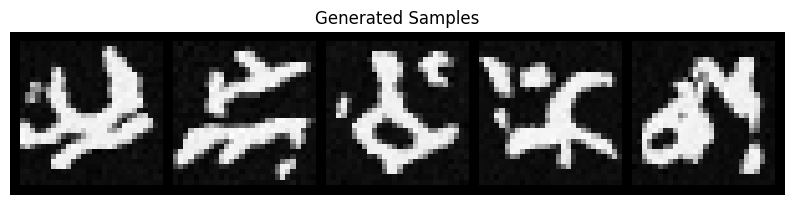

  Step 600/750, Loss: 0.0620
  Step 700/750, Loss: 0.0585

Training - Epoch 14 average loss: 0.0583
Running validation...
Validation - Epoch 14 average loss: 0.0581
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0581)

Epoch 15/30
--------------------
  Step 0/750, Loss: 0.0579
  Step 100/750, Loss: 0.0576
  Step 200/750, Loss: 0.0595
  Step 300/750, Loss: 0.0581
  Step 400/750, Loss: 0.0608
  Step 500/750, Loss: 0.0635
  Generating samples...


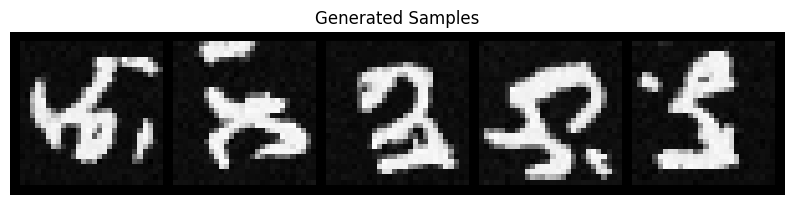

  Step 600/750, Loss: 0.0596
  Step 700/750, Loss: 0.0619

Training - Epoch 15 average loss: 0.0578
Running validation...
Validation - Epoch 15 average loss: 0.0581
Learning rate: 0.001000

Generating samples for visual progress check...


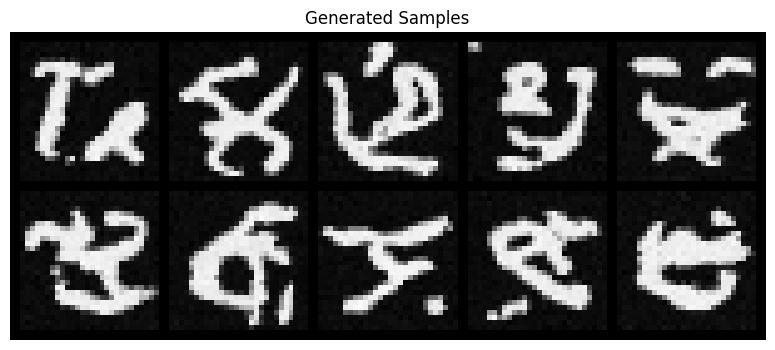

No improvement for 1/10 epochs

Epoch 16/30
--------------------
  Step 0/750, Loss: 0.0638
  Step 100/750, Loss: 0.0574
  Step 200/750, Loss: 0.0641
  Step 300/750, Loss: 0.0545
  Step 400/750, Loss: 0.0535
  Step 500/750, Loss: 0.0548
  Generating samples...


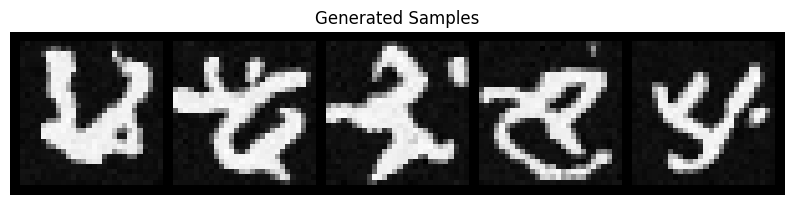

  Step 600/750, Loss: 0.0624
  Step 700/750, Loss: 0.0564

Training - Epoch 16 average loss: 0.0576
Running validation...
Validation - Epoch 16 average loss: 0.0597
Learning rate: 0.001000
No improvement for 2/10 epochs


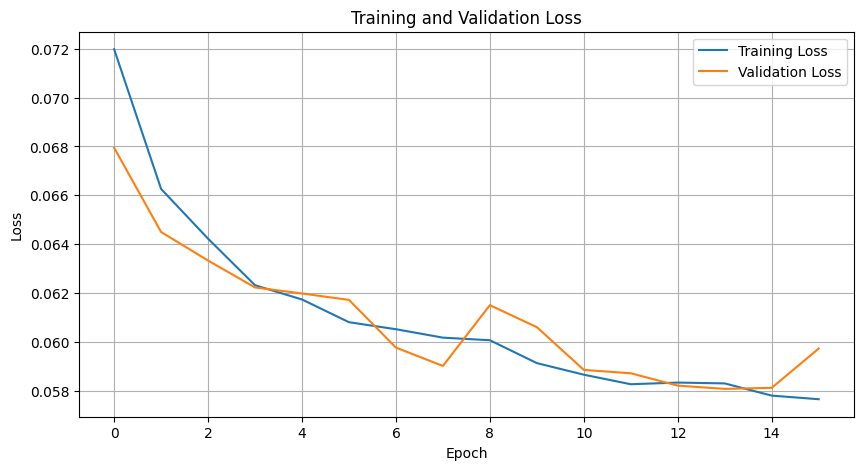


Epoch 17/30
--------------------
  Step 0/750, Loss: 0.0591
  Step 100/750, Loss: 0.0650
  Step 200/750, Loss: 0.0566
  Step 300/750, Loss: 0.0585
  Step 400/750, Loss: 0.0608
  Step 500/750, Loss: 0.0561
  Generating samples...


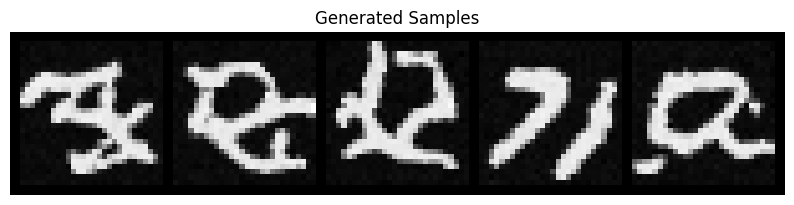

  Step 600/750, Loss: 0.0497
  Step 700/750, Loss: 0.0569

Training - Epoch 17 average loss: 0.0574
Running validation...
Validation - Epoch 17 average loss: 0.0574
Learning rate: 0.001000

Generating samples for visual progress check...


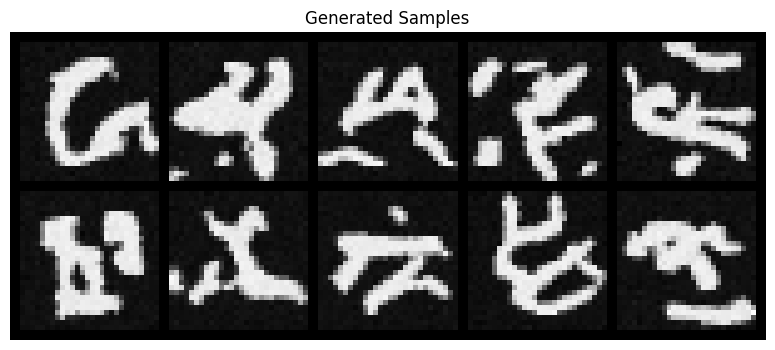

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0574)

Epoch 18/30
--------------------
  Step 0/750, Loss: 0.0696
  Step 100/750, Loss: 0.0563
  Step 200/750, Loss: 0.0639
  Step 300/750, Loss: 0.0592
  Step 400/750, Loss: 0.0585
  Step 500/750, Loss: 0.0563
  Generating samples...


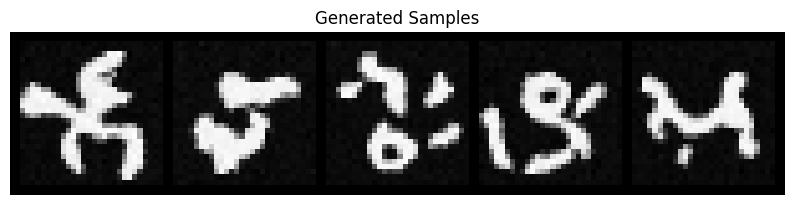

  Step 600/750, Loss: 0.0603
  Step 700/750, Loss: 0.0676

Training - Epoch 18 average loss: 0.0576
Running validation...
Validation - Epoch 18 average loss: 0.0572
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0572)

Epoch 19/30
--------------------
  Step 0/750, Loss: 0.0614
  Step 100/750, Loss: 0.0540
  Step 200/750, Loss: 0.0534
  Step 300/750, Loss: 0.0636
  Step 400/750, Loss: 0.0522
  Step 500/750, Loss: 0.0610
  Generating samples...


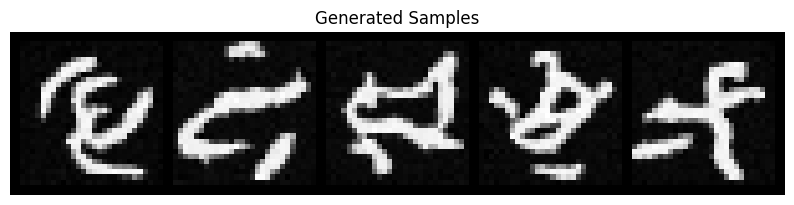

  Step 600/750, Loss: 0.0510
  Step 700/750, Loss: 0.0563

Training - Epoch 19 average loss: 0.0573
Running validation...
Validation - Epoch 19 average loss: 0.0568
Learning rate: 0.001000

Generating samples for visual progress check...


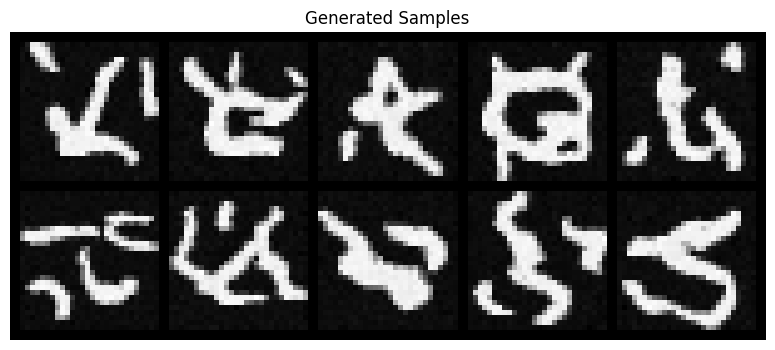

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0568)

Epoch 20/30
--------------------
  Step 0/750, Loss: 0.0538
  Step 100/750, Loss: 0.0486
  Step 200/750, Loss: 0.0598
  Step 300/750, Loss: 0.0558
  Step 400/750, Loss: 0.0621
  Step 500/750, Loss: 0.0497
  Generating samples...


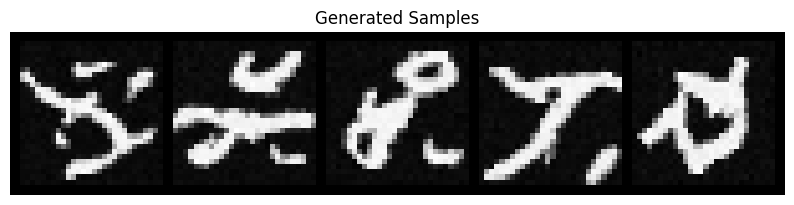

  Step 600/750, Loss: 0.0633
  Step 700/750, Loss: 0.0536

Training - Epoch 20 average loss: 0.0575
Running validation...
Validation - Epoch 20 average loss: 0.0580
Learning rate: 0.001000
No improvement for 1/10 epochs

Epoch 21/30
--------------------
  Step 0/750, Loss: 0.0534
  Step 100/750, Loss: 0.0650
  Step 200/750, Loss: 0.0616
  Step 300/750, Loss: 0.0557
  Step 400/750, Loss: 0.0558
  Step 500/750, Loss: 0.0541
  Generating samples...


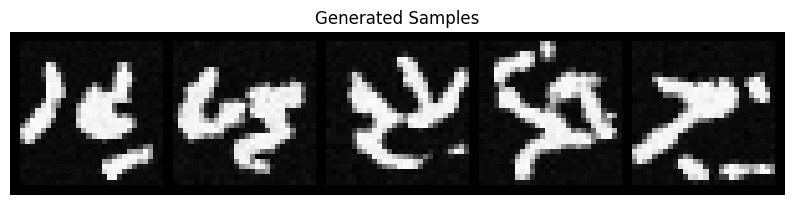

  Step 600/750, Loss: 0.0624
  Step 700/750, Loss: 0.0536

Training - Epoch 21 average loss: 0.0571
Running validation...
Validation - Epoch 21 average loss: 0.0569
Learning rate: 0.001000

Generating samples for visual progress check...


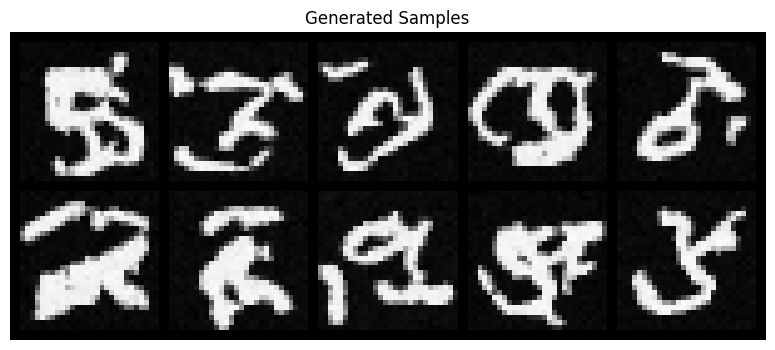

No improvement for 2/10 epochs


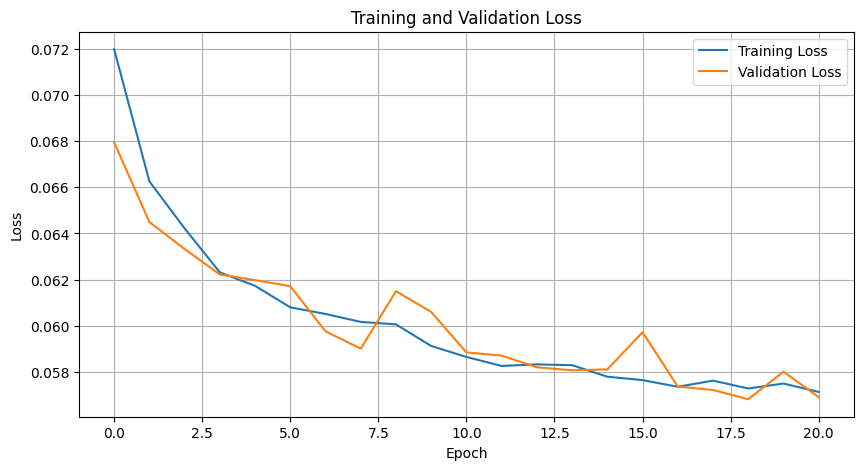


Epoch 22/30
--------------------
  Step 0/750, Loss: 0.0527
  Step 100/750, Loss: 0.0523
  Step 200/750, Loss: 0.0531
  Step 300/750, Loss: 0.0581
  Step 400/750, Loss: 0.0504
  Step 500/750, Loss: 0.0567
  Generating samples...


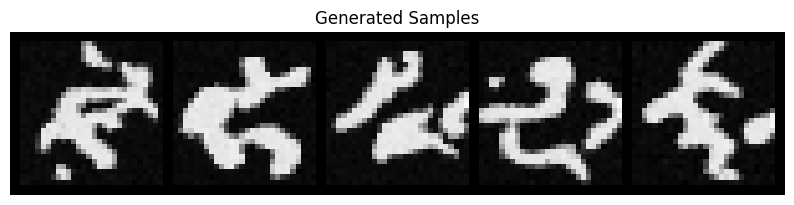

  Step 600/750, Loss: 0.0561
  Step 700/750, Loss: 0.0585

Training - Epoch 22 average loss: 0.0569
Running validation...
Validation - Epoch 22 average loss: 0.0566
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0566)

Epoch 23/30
--------------------
  Step 0/750, Loss: 0.0614
  Step 100/750, Loss: 0.0553
  Step 200/750, Loss: 0.0603
  Step 300/750, Loss: 0.0640
  Step 400/750, Loss: 0.0639
  Step 500/750, Loss: 0.0587
  Generating samples...


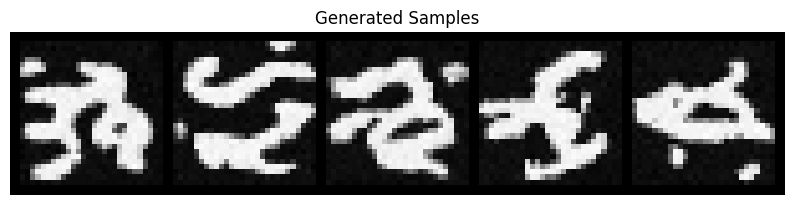

  Step 600/750, Loss: 0.0502
  Step 700/750, Loss: 0.0597

Training - Epoch 23 average loss: 0.0568
Running validation...
Validation - Epoch 23 average loss: 0.0559
Learning rate: 0.001000

Generating samples for visual progress check...


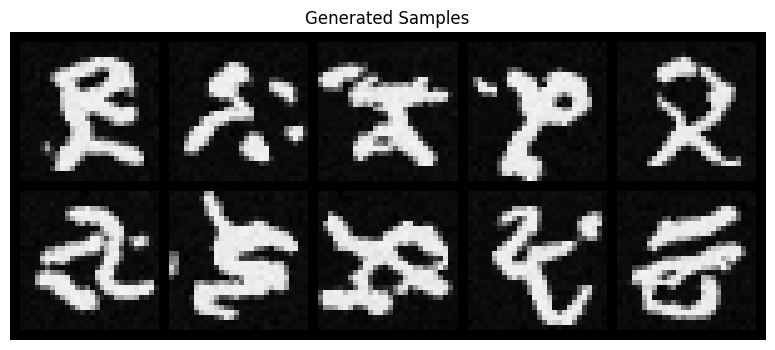

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0559)

Epoch 24/30
--------------------
  Step 0/750, Loss: 0.0535
  Step 100/750, Loss: 0.0539
  Step 200/750, Loss: 0.0557
  Step 300/750, Loss: 0.0566
  Step 400/750, Loss: 0.0594
  Step 500/750, Loss: 0.0659
  Generating samples...


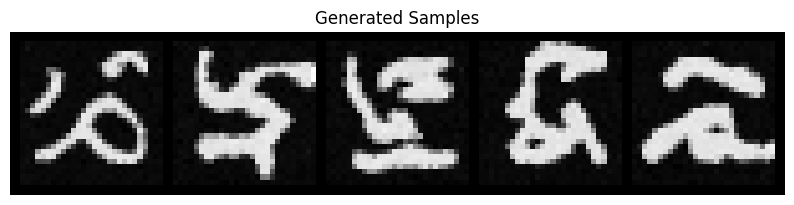

  Step 600/750, Loss: 0.0487
  Step 700/750, Loss: 0.0587

Training - Epoch 24 average loss: 0.0569
Running validation...
Validation - Epoch 24 average loss: 0.0569
Learning rate: 0.001000
No improvement for 1/10 epochs

Epoch 25/30
--------------------
  Step 0/750, Loss: 0.0596
  Step 100/750, Loss: 0.0543
  Step 200/750, Loss: 0.0585
  Step 300/750, Loss: 0.0587
  Step 400/750, Loss: 0.0591
  Step 500/750, Loss: 0.0544
  Generating samples...


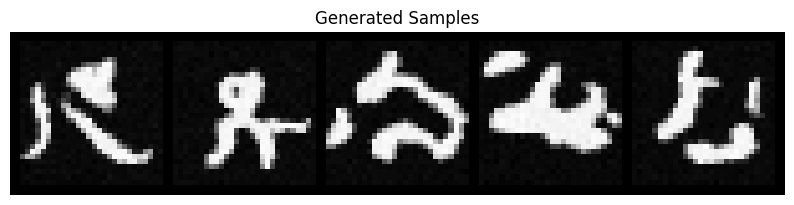

  Step 600/750, Loss: 0.0451
  Step 700/750, Loss: 0.0493

Training - Epoch 25 average loss: 0.0566
Running validation...
Validation - Epoch 25 average loss: 0.0574
Learning rate: 0.001000

Generating samples for visual progress check...


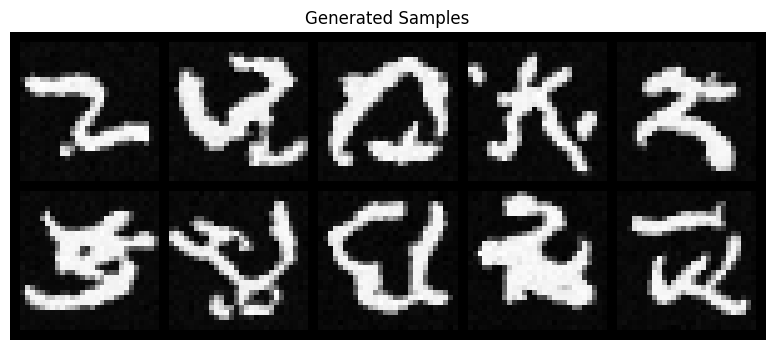

No improvement for 2/10 epochs

Epoch 26/30
--------------------
  Step 0/750, Loss: 0.0580
  Step 100/750, Loss: 0.0589
  Step 200/750, Loss: 0.0641
  Step 300/750, Loss: 0.0569
  Step 400/750, Loss: 0.0517
  Step 500/750, Loss: 0.0641
  Generating samples...


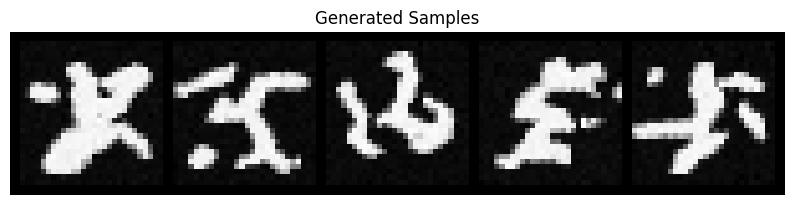

  Step 600/750, Loss: 0.0612
  Step 700/750, Loss: 0.0510

Training - Epoch 26 average loss: 0.0564
Running validation...
Validation - Epoch 26 average loss: 0.0567
Learning rate: 0.001000
No improvement for 3/10 epochs


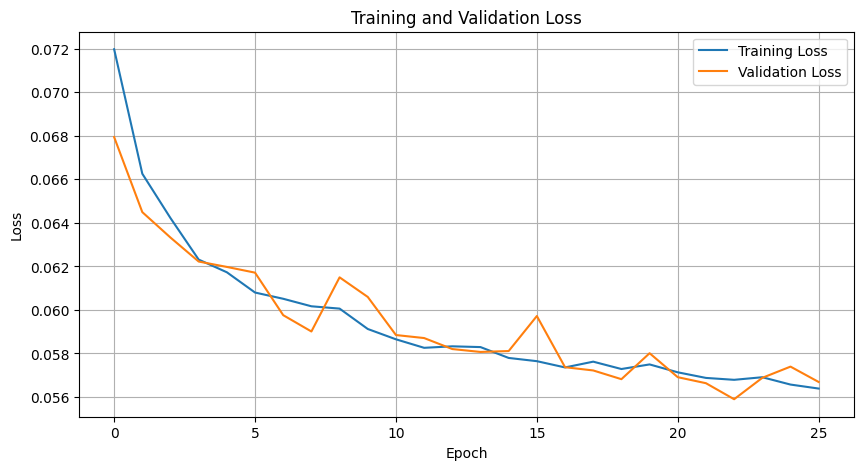


Epoch 27/30
--------------------
  Step 0/750, Loss: 0.0545
  Step 100/750, Loss: 0.0560
  Step 200/750, Loss: 0.0617
  Step 300/750, Loss: 0.0494
  Step 400/750, Loss: 0.0525
  Step 500/750, Loss: 0.0627
  Generating samples...


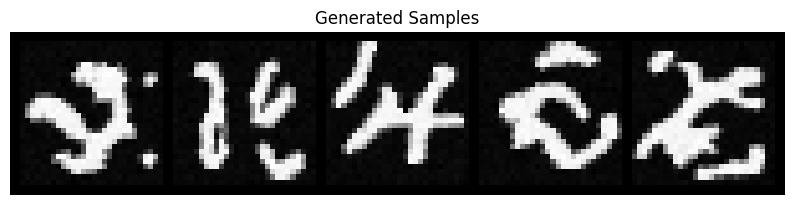

  Step 600/750, Loss: 0.0606
  Step 700/750, Loss: 0.0500

Training - Epoch 27 average loss: 0.0566
Running validation...
Validation - Epoch 27 average loss: 0.0563
Learning rate: 0.001000

Generating samples for visual progress check...


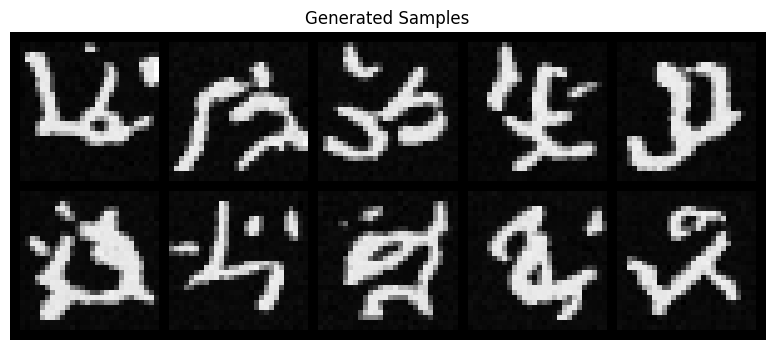

No improvement for 4/10 epochs

Epoch 28/30
--------------------
  Step 0/750, Loss: 0.0517
  Step 100/750, Loss: 0.0615
  Step 200/750, Loss: 0.0585
  Step 300/750, Loss: 0.0552
  Step 400/750, Loss: 0.0565
  Step 500/750, Loss: 0.0586
  Generating samples...


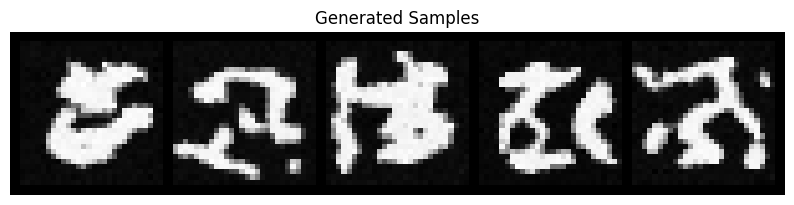

  Step 600/750, Loss: 0.0577
  Step 700/750, Loss: 0.0531

Training - Epoch 28 average loss: 0.0561
Running validation...
Validation - Epoch 28 average loss: 0.0565
Learning rate: 0.001000
No improvement for 5/10 epochs

Epoch 29/30
--------------------
  Step 0/750, Loss: 0.0510
  Step 100/750, Loss: 0.0557
  Step 200/750, Loss: 0.0574
  Step 300/750, Loss: 0.0527
  Step 400/750, Loss: 0.0552
  Step 500/750, Loss: 0.0515
  Generating samples...


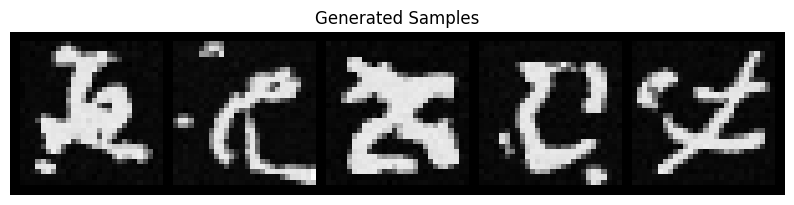

  Step 600/750, Loss: 0.0530
  Step 700/750, Loss: 0.0576

Training - Epoch 29 average loss: 0.0564
Running validation...
Validation - Epoch 29 average loss: 0.0561
Learning rate: 0.000500

Generating samples for visual progress check...


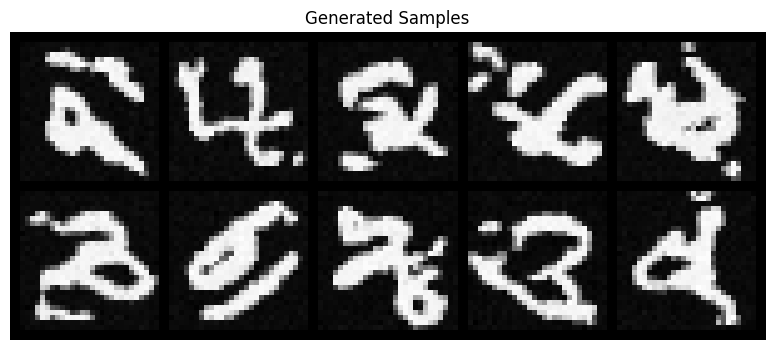

No improvement for 6/10 epochs

Epoch 30/30
--------------------
  Step 0/750, Loss: 0.0507
  Step 100/750, Loss: 0.0564
  Step 200/750, Loss: 0.0488
  Step 300/750, Loss: 0.0495
  Step 400/750, Loss: 0.0476
  Step 500/750, Loss: 0.0553
  Generating samples...


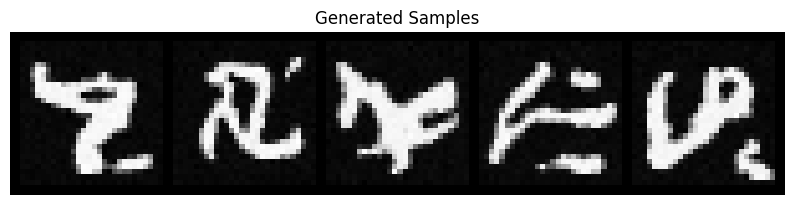

  Step 600/750, Loss: 0.0474
  Step 700/750, Loss: 0.0571

Training - Epoch 30 average loss: 0.0549
Running validation...
Validation - Epoch 30 average loss: 0.0550
Learning rate: 0.000500

Generating samples for visual progress check...


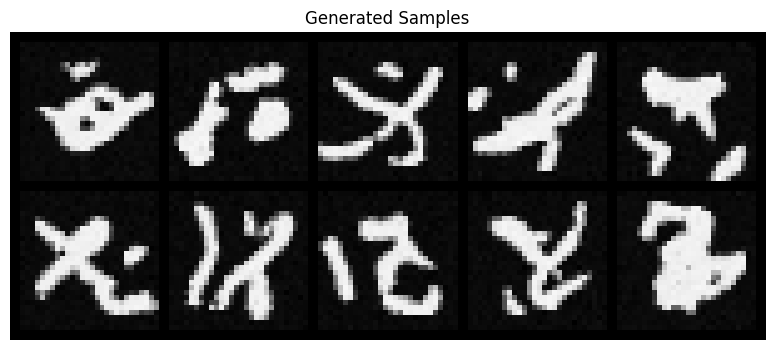

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0550)


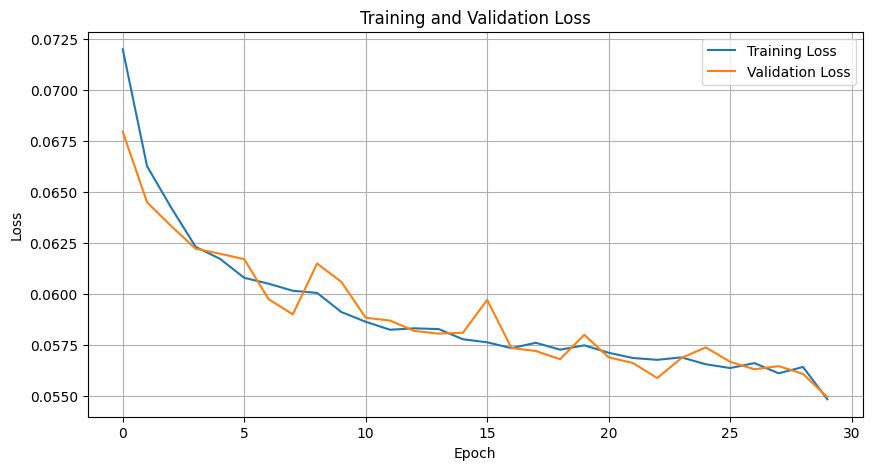


TRAINING COMPLETE
Best validation loss: 0.0550
Generating final samples...


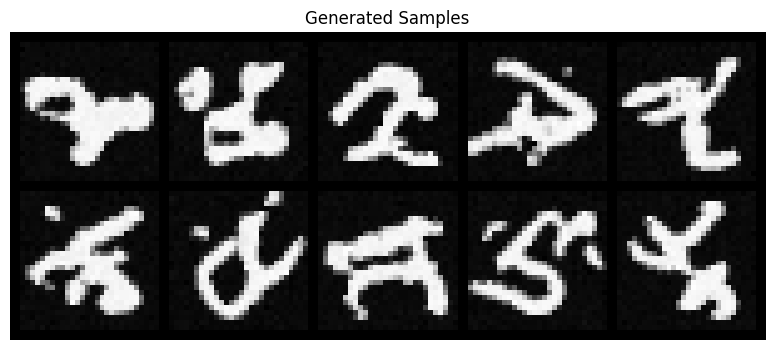

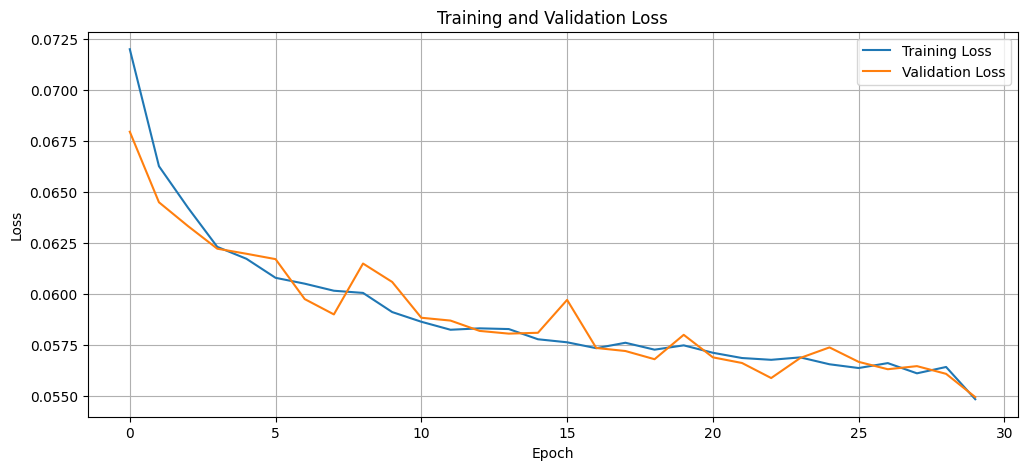

In [ ]:
# Implementation of the main training loop
# Training configuration
early_stopping_patience = 10  # Number of epochs without improvement before stopping
gradient_clip_value = 1.0     # Maximum gradient norm for stability
display_frequency = 100       # How often to show progress (in steps)
generate_frequency = 500      # How often to generate samples (in steps)

# Progress tracking variables
best_loss = float('inf')
train_losses = []
val_losses = []
no_improve_epochs = 0

# Training loop
print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)
model.train()

# Wrap the training loop in a try-except block for better error handling:
try:
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print("-" * 20)

        # Training phase
        model.train()
        epoch_losses = []

        # Process each batch
        for step, (images, labels) in enumerate(train_dataloader):  # Fixed: dataloader → train_dataloader
            images = images.to(device)
            labels = labels.to(device)

            # Training step
            optimizer.zero_grad()
            loss = train_step(images, labels)
            loss.backward()

            # Add gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip_value)

            optimizer.step()
            epoch_losses.append(loss.item())

            # Show progress at regular intervals
            if step % display_frequency == 0:
                print(f"  Step {step}/{len(train_dataloader)}, Loss: {loss.item():.4f}")

                # Generate samples less frequently to save time
                if step % generate_frequency == 0 and step > 0:
                    print("  Generating samples...")
                    generate_samples(model, n_samples=5)

        # End of epoch - calculate average training loss
        avg_train_loss = sum(epoch_losses) / len(epoch_losses)
        train_losses.append(avg_train_loss)
        print(f"\nTraining - Epoch {epoch+1} average loss: {avg_train_loss:.4f}")

        # Validation phase
        model.eval()
        val_epoch_losses = []
        print("Running validation...")

        with torch.no_grad():  # Disable gradients for validation
            for val_images, val_labels in val_dataloader:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)

                # Calculate validation loss
                val_loss = train_step(val_images, val_labels)
                val_epoch_losses.append(val_loss.item())

        # Calculate average validation loss
        avg_val_loss = sum(val_epoch_losses) / len(val_epoch_losses)
        val_losses.append(avg_val_loss)
        print(f"Validation - Epoch {epoch+1} average loss: {avg_val_loss:.4f}")

        # Learning rate scheduling based on validation loss
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Learning rate: {current_lr:.6f}")

        # Generate samples at the end of each epoch
        if epoch % 2 == 0 or epoch == EPOCHS - 1:
            print("\nGenerating samples for visual progress check...")
            generate_samples(model, n_samples=10)

        # Save best model based on validation loss
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            # Use safe_save_model instead of just saving state_dict
            safe_save_model(model, 'best_diffusion_model.pt', optimizer, epoch, best_loss)
            print(f"✓ New best model saved! (Val Loss: {best_loss:.4f})")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            print(f"No improvement for {no_improve_epochs}/{early_stopping_patience} epochs")

        # Early stopping
        if no_improve_epochs >= early_stopping_patience:
            print("\nEarly stopping triggered! No improvement in validation loss.")
            break

        # Plot loss curves every few epochs
        if epoch % 5 == 0 or epoch == EPOCHS - 1:
            plt.figure(figsize=(10, 5))
            plt.plot(train_losses, label='Training Loss')
            plt.plot(val_losses, label='Validation Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('Training and Validation Loss')
            plt.legend()
            plt.grid(True)
            plt.show()

except Exception as e:
    print(f"Error during training: {e}")

# Final wrap-up
print("\n" + "="*50)
print("TRAINING COMPLETE")
print("="*50)
print(f"Best validation loss: {best_loss:.4f}")

# Generate final samples
print("Generating final samples...")
try:
    generate_samples(model, n_samples=10)
except:
    pass

# Display final loss curves
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Clean up memory
torch.cuda.empty_cache()


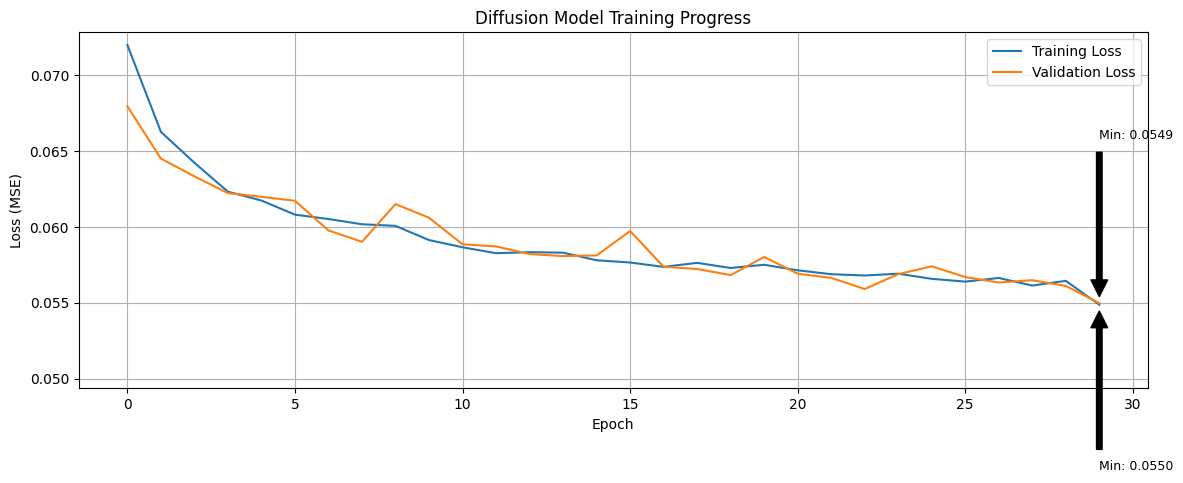


Training Statistics:
------------------------------
Starting training loss:    0.0720
Final training loss:       0.0549
Best training loss:        0.0549
Training loss improvement: 23.8%

Validation Statistics:
------------------------------
Starting validation loss: 0.0679
Final validation loss:    0.0550
Best validation loss:     0.0550


In [ ]:
# Plot training progress
plt.figure(figsize=(12, 5))

# Plot training and validation losses for comparison
if len(train_losses) > 0:
    plt.plot(train_losses, label='Training Loss')
if len(val_losses) > 0:  # Only plot validation if it exists
    plt.plot(val_losses, label='Validation Loss')

# Improve the plot with better labels and styling
plt.title('Diffusion Model Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
if len(train_losses) > 0 or len(val_losses) > 0:
    plt.legend()
plt.grid(True)

# Add annotations for key points
if len(train_losses) > 1:
    min_train_idx = train_losses.index(min(train_losses))
    plt.annotate(f'Min: {min(train_losses):.4f}',
                 xy=(min_train_idx, min(train_losses)),
                 xytext=(min_train_idx, min(train_losses)*1.2),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=9)

# Add validation min point if available
if len(val_losses) > 1:
    min_val_idx = val_losses.index(min(val_losses))
    plt.annotate(f'Min: {min(val_losses):.4f}',
                xy=(min_val_idx, min(val_losses)),
                xytext=(min_val_idx, min(val_losses)*0.8),
                arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=9)

# Set y-axis to start from 0 or slightly lower than min value
if len(train_losses) > 0 or len(val_losses) > 0:
    min_val = min(
        min(train_losses) if train_losses else float('inf'),
        min(val_losses) if val_losses else float('inf')
    )
    if min_val != float('inf'):
        plt.ylim(bottom=max(0, min_val * 0.9))

plt.tight_layout()
plt.show()

# Add statistics summary for students to analyze
print("\nTraining Statistics:")
print("-" * 30)
if train_losses:
    print(f"Starting training loss:    {train_losses[0]:.4f}")
    print(f"Final training loss:       {train_losses[-1]:.4f}")
    print(f"Best training loss:        {min(train_losses):.4f}")
    if train_losses[0] != 0:
        print(f"Training loss improvement: {((train_losses[0] - min(train_losses)) / train_losses[0] * 100):.1f}%")
else:
    print("No training data available yet. Please run the training loop!")

if val_losses:
    print("\nValidation Statistics:")
    print("-" * 30)
    print(f"Starting validation loss: {val_losses[0]:.4f}")
    print(f"Final validation loss:    {val_losses[-1]:.4f}")
    print(f"Best validation loss:     {min(val_losses):.4f}")

# STUDENT EXERCISE:
# 1. Try modifying this plot to show a smoothed version of the losses
# 2. Create a second plot showing the ratio of validation to training loss
#    (which can indicate overfitting when the ratio increases)


## Step 6: Generating New Images

Now that our model is trained, let's generate some new images! We can:
1. Generate specific numbers
2. Generate multiple versions of each number
3. See how the generation process works step by step

Generating 4 versions of number 0...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 1...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 2...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 3...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 4...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 

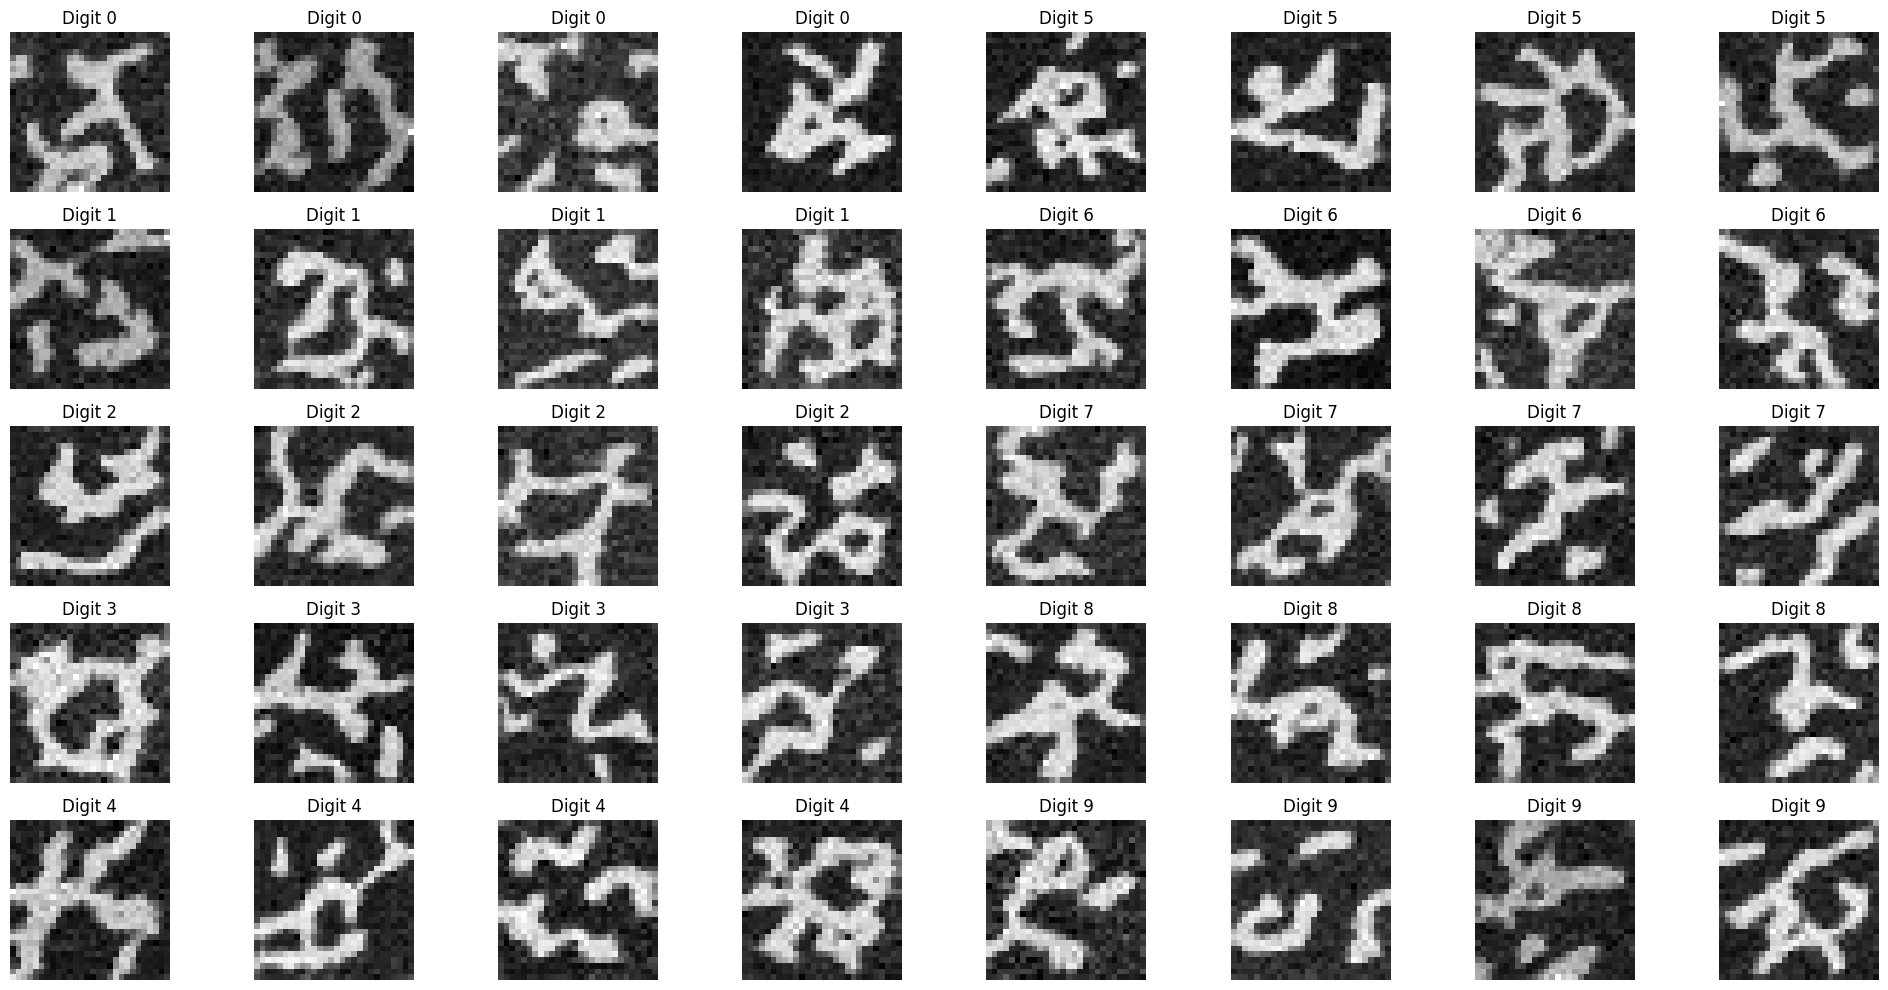


STUDENT ACTIVITY: Generating numbers with different noise seeds
Generating 5 versions of number 5...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


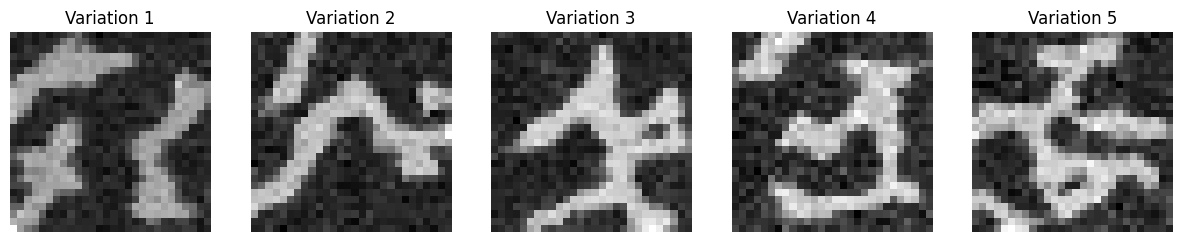

In [ ]:
# Fix the remove_noise function first
@torch.no_grad()
def remove_noise(x_t, t, model, c, c_mask):
    predicted_noise = model(x_t, t, c, c_mask)

    alpha_t = alpha[t].reshape(-1, 1, 1, 1)
    alpha_bar_t = alpha_bar[t].reshape(-1, 1, 1, 1)
    beta_t = beta[t].reshape(-1, 1, 1, 1)

    # ADD THE MISSING VARIABLE HERE:
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1 - alpha_bar_t)

    if t[0] == 0:
        return x_t
    else:
        mean = (1 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise
        )
        noise = torch.randn_like(x_t)
        return mean + torch.sqrt(beta_t) * noise

def generate_number(model, number, n_samples=4):
    """
    Generate multiple versions of a specific number using the diffusion model.

    Args:
        model (nn.Module): The trained diffusion model
        number (int): The digit to generate (0-9)
        n_samples (int): Number of variations to generate

    Returns:
        torch.Tensor: Generated images of shape [n_samples, IMG_CH, IMG_SIZE, IMG_SIZE]
    """
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # No need for gradients during generation
        # Start with random noise
        samples = torch.randn(n_samples, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up the number we want to generate
        c = torch.full((n_samples,), number).to(device)
        c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
        # Correctly sized conditioning mask
        c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

        # Display progress information
        print(f"Generating {n_samples} versions of number {number}...")

        # Remove noise step by step
        for t in range(n_steps-1, -1, -1):
            t_batch = torch.full((n_samples,), t).to(device)
            samples = remove_noise(samples, t_batch, model, c_one_hot, c_mask)

            # Optional: Display occasional progress updates
            if t % (n_steps // 5) == 0:
                print(f"  Denoising step {n_steps-1-t}/{n_steps-1} completed")

        return samples

# Generate 4 versions of each number
plt.figure(figsize=(20, 10))
for i in range(10):
    # Generate samples for current digit
    samples = generate_number(model, i, n_samples=4)

    # Display each sample
    for j in range(4):
        # Use 2 rows, 10 digits per row, 4 samples per digit
        # i//5 determines the row (0 or 1)
        # i%5 determines the position in the row (0-4)
        # j is the sample index within each digit (0-3)
        plt.subplot(5, 8, (i%5)*8 + (i//5)*4 + j + 1)

        # Display the image correctly based on channel configuration
        if IMG_CH == 1:  # Grayscale
            plt.imshow(samples[j][0].cpu(), cmap='gray')
        else:  # Color image
            img = samples[j].permute(1, 2, 0).cpu()
            # Rescale from [-1, 1] to [0, 1] if needed
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)

        plt.title(f'Digit {i}')
        plt.axis('off')

plt.tight_layout()
plt.show()

# STUDENT ACTIVITY: Try generating the same digit with different noise seeds
# This shows the variety of styles the model can produce
print("\nSTUDENT ACTIVITY: Generating numbers with different noise seeds")

# Helper function to generate with seed
def generate_with_seed(number, seed_value=42, n_samples=10):
    torch.manual_seed(seed_value)
    return generate_number(model, number, n_samples)

# Pick a image and show many variations
# Generate variations for the digit 5
variations = generate_with_seed(5, seed_value=42, n_samples=5)
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    if IMG_CH == 1:
        plt.imshow(variations[i][0].cpu(), cmap='gray')
    else:
        img = variations[i].permute(1, 2, 0).cpu()
        if img.min() < 0:
            img = (img + 1) / 2
        plt.imshow(img)
    plt.title(f'Variation {i+1}')
    plt.axis('off')
plt.show()

## Step 7: Watching the Generation Process

Let's see how our model turns random noise into clear images, step by step. This helps us understand how the diffusion process works!


Generating number 0:


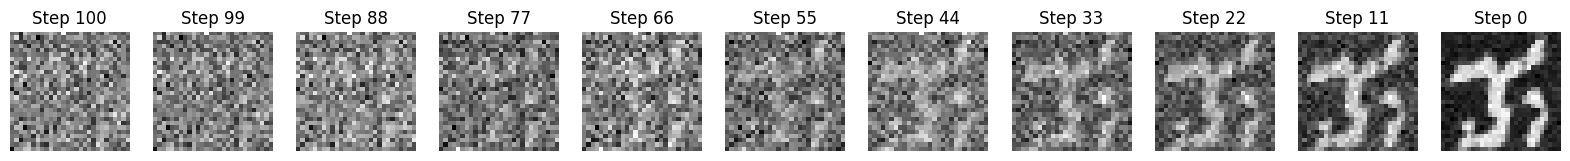


Generating number 3:


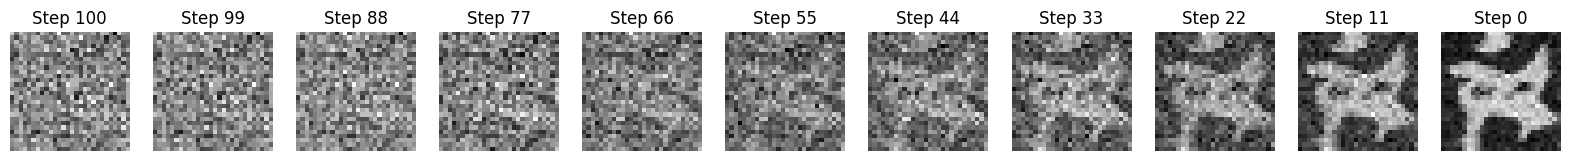


Generating number 7:


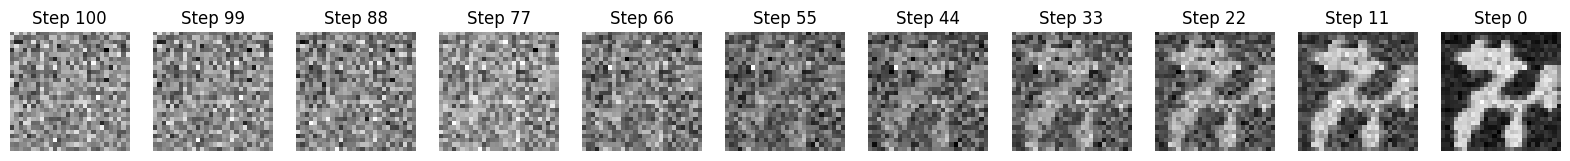

In [ ]:
def visualize_generation_steps(model, number, n_preview_steps=10):
    """
    Show how an image evolves from noise to a clear number
    """
    model.eval()
    with torch.no_grad():
        # Start with random noise
        x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up which number to generate
        c = torch.tensor([number]).to(device)
        c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)

        # FIX: Create mask with shape [batch_size, 1] instead of [batch_size, 10]
        c_mask = torch.ones_like(c.unsqueeze(-1)).float().to(device)

        # Calculate which steps to show
        steps_to_show = torch.linspace(n_steps-1, 0, n_preview_steps).long()

        # Store images for visualization
        images = []
        images.append(x[0].cpu())

        # Remove noise step by step
        for t in range(n_steps-1, -1, -1):
            t_batch = torch.full((1,), t).to(device)
            x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            if t in steps_to_show:
                images.append(x[0].cpu())

        # Show the progression
        plt.figure(figsize=(20, 3))
        for i, img in enumerate(images):
            plt.subplot(1, len(images), i+1)
            if IMG_CH == 1:
                plt.imshow(img[0], cmap='gray')
            else:
                img = img.permute(1, 2, 0)
                if img.min() < 0:
                    img = (img + 1) / 2
                plt.imshow(img)
            step = n_steps if i == 0 else steps_to_show[i-1]
            plt.title(f'Step {step}')
            plt.axis('off')
        plt.show()

# Show generation process for a few numbers
for number in [0, 3, 7]:
    print(f"\nGenerating number {number}:")
    visualize_generation_steps(model, number)

## Step 8: Adding CLIP Evaluation

[CLIP](https://openai.com/research/clip) is a powerful AI model that can understand both images and text. We'll use it to:
1. Evaluate how realistic our generated images are
2. Score how well they match their intended numbers
3. Help guide the generation process towards better quality

In [ ]:
## Step 8: Adding CLIP Evaluation

# CLIP (Contrastive Language-Image Pre-training) is a powerful model by OpenAI that connects text and images.
# We'll use it to evaluate how recognizable our generated digits are by measuring how strongly
# the CLIP model associates our generated images with text descriptions like "an image of the digit 7".

# First, we need to install CLIP and its dependencies
print("Setting up CLIP (Contrastive Language-Image Pre-training) model...")

# Track installation status
clip_available = False

try:
    # Install dependencies first - these help CLIP process text and images
    print("Installing CLIP dependencies...")
    !pip install -q ftfy regex tqdm

    # Install CLIP from GitHub
    print("Installing CLIP from GitHub repository...")
    !pip install -q git+https://github.com/openai/CLIP.git

    # Import and verify CLIP is working
    print("Importing CLIP...")
    import clip

    # Test that CLIP is functioning
    models = clip.available_models()
    print(f"✓ CLIP installation successful! Available models: {models}")
    clip_available = True

except ImportError:
    print("❌ Error importing CLIP. Installation might have failed.")
    print("Try manually running: !pip install git+https://github.com/openai/CLIP.git")
    print("If you're in a Colab notebook, try restarting the runtime after installation.")

except Exception as e:
    print(f"❌ Error during CLIP setup: {e}")
    print("Some CLIP functionality may not work correctly.")

# Provide guidance based on installation result
if clip_available:
    print("\nCLIP is now available for evaluating your generated images!")
else:
    print("\nWARNING: CLIP installation failed. We'll skip the CLIP evaluation parts.")

# Import necessary libraries
import functools
import torch.nn.functional as F


Setting up CLIP (Contrastive Language-Image Pre-training) model...
Installing CLIP dependencies...
Installing CLIP from GitHub repository...
  Preparing metadata (setup.py) ... done
Importing CLIP...
✓ CLIP installation successful! Available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']

CLIP is now available for evaluating your generated images!


 Below we are createing  a helper function to manage GPU memory when using CLIP. CLIP can be memory-intensive, so this will help prevent out-of-memory errors:

In [ ]:
# Memory management decorator to prevent GPU OOM errors
def manage_gpu_memory(func):
    """
    Decorator that ensures proper GPU memory management.

    This wraps functions that might use large amounts of GPU memory,
    making sure memory is properly freed after function execution.
    """
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        if torch.cuda.is_available():
            # Clear cache before running function
            torch.cuda.empty_cache()
            try:
                return func(*args, **kwargs)
            finally:
                # Clear cache after running function regardless of success/failure
                torch.cuda.empty_cache()
        return func(*args, **kwargs)
    return wrapper

✓ Successfully loaded CLIP model: VisionTransformer

Generating and evaluating number 0...
Generating 4 versions of number 0...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


/tmp/ipykernel_9312/3974156644.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


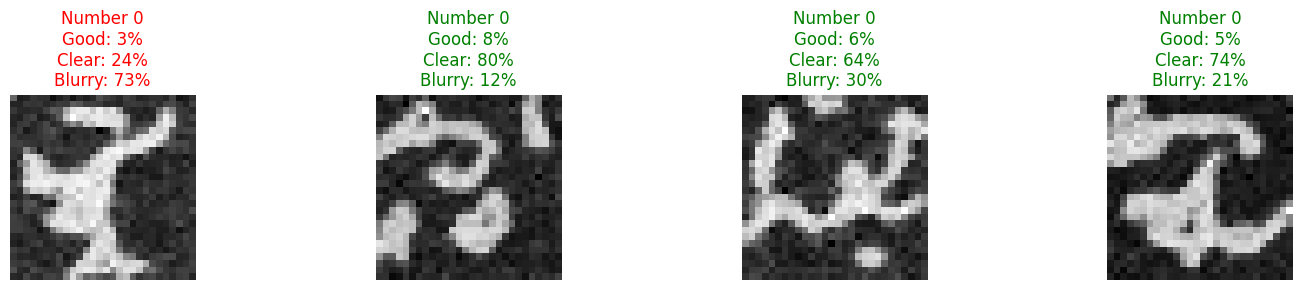


Generating and evaluating number 1...
Generating 4 versions of number 1...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


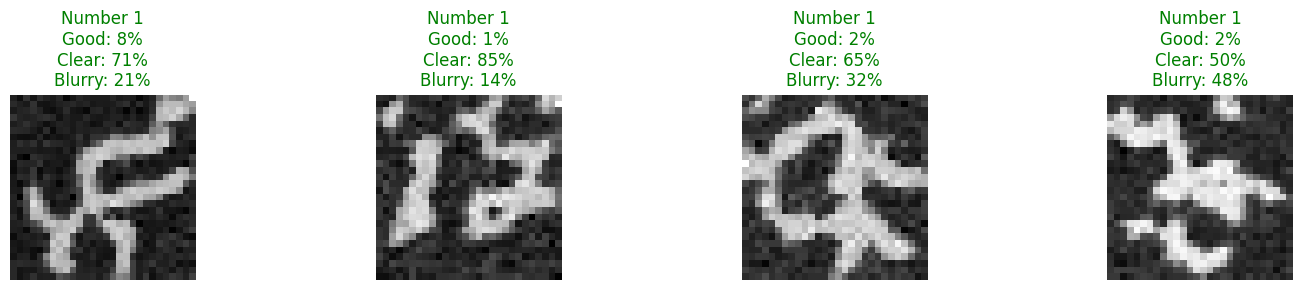


Generating and evaluating number 2...
Generating 4 versions of number 2...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


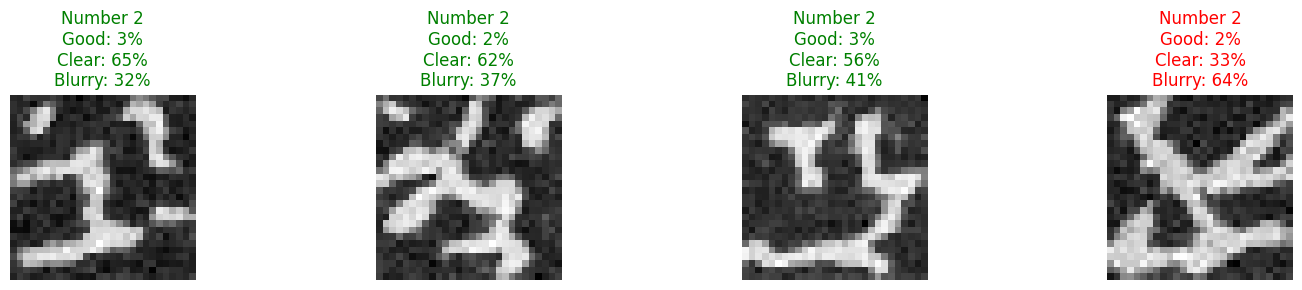


Generating and evaluating number 3...
Generating 4 versions of number 3...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


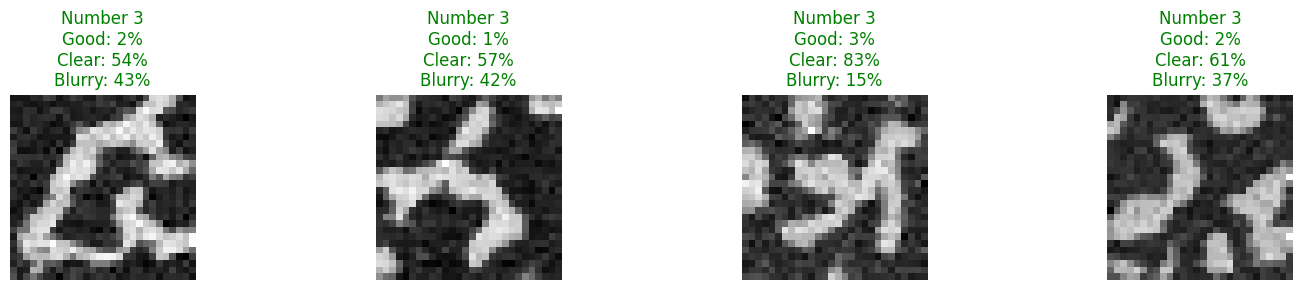


Generating and evaluating number 4...
Generating 4 versions of number 4...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


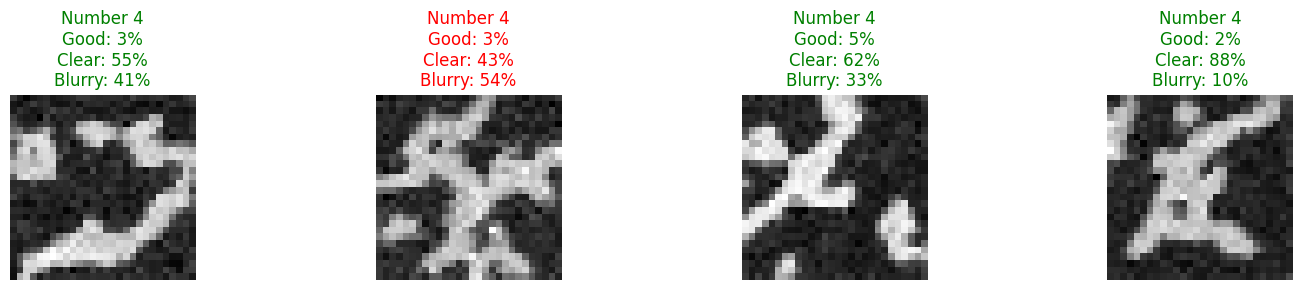


Generating and evaluating number 5...
Generating 4 versions of number 5...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


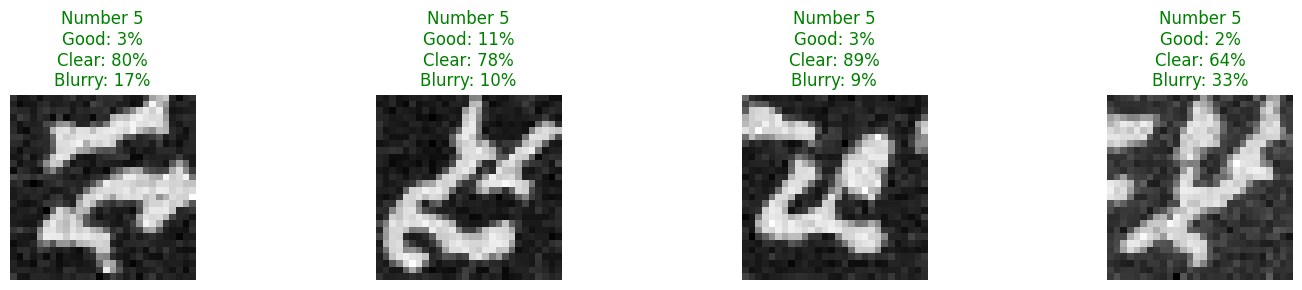


Generating and evaluating number 6...
Generating 4 versions of number 6...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


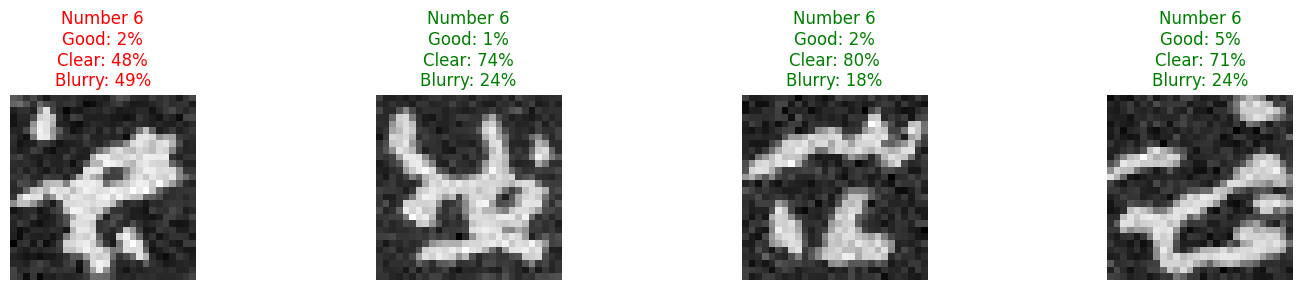


Generating and evaluating number 7...
Generating 4 versions of number 7...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


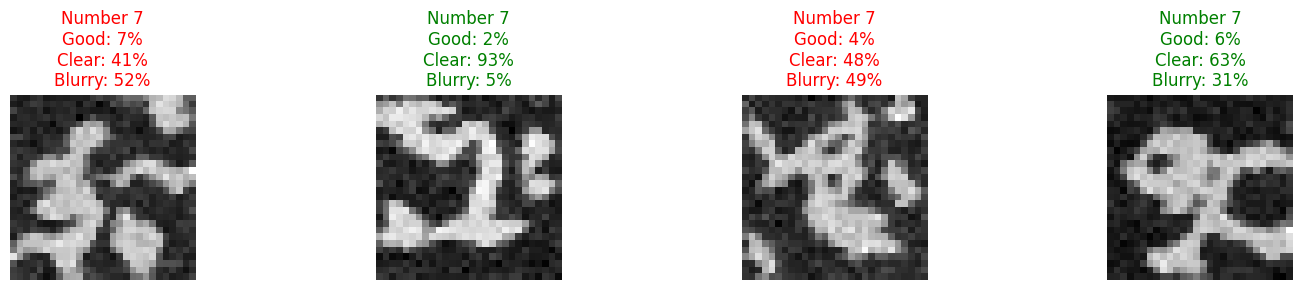


Generating and evaluating number 8...
Generating 4 versions of number 8...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


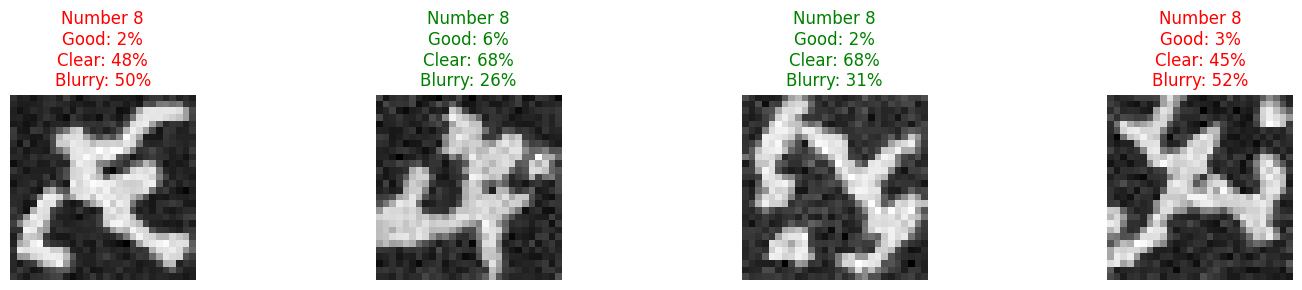


Generating and evaluating number 9...
Generating 4 versions of number 9...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


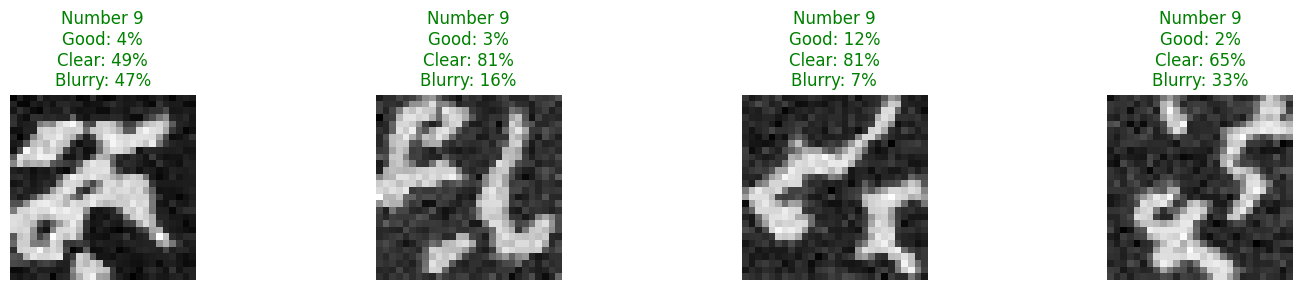


STUDENT ACTIVITY:
Try the code below to evaluate a larger sample of a specific digit

# Example: Generate and evaluate 10 examples of the digit 6
# digit = 6
# samples = generate_number(model, digit, n_samples=10)
# similarities = evaluate_with_clip(samples, digit)
#
# # Calculate what percentage of samples CLIP considers "good quality"
# # (either "good handwritten" or "clear" score exceeds "blurry" score)
# good_or_clear = (similarities[:,0] + similarities[:,1] > similarities[:,2]).float().mean()
# print(f"CLIP recognized {good_or_clear.item()*100:.1f}% of the digits as good examples of {digit}")
#
# # Display a grid of samples with their quality scores
# plt.figure(figsize=(15, 8))
# for i in range(len(samples)):
#     plt.subplot(2, 5, i+1)
#     plt.imshow(samples[i][0].cpu(), cmap='gray')
#     quality = "Good" if similarities[i,0] + similarities[i,1] > similarities[i,2] else "Poor"
#     plt.title(f"Sample {i+1}: {quality}", color='green' if quality == "Good" else 'red')
#     

In [ ]:
#==============================================================================
# Step 8: CLIP Model Loading and Evaluation Setup
#==============================================================================
# CLIP (Contrastive Language-Image Pre-training) is a neural network that connects
# vision and language. It was trained on 400 million image-text pairs to understand
# the relationship between images and their descriptions.
# We use it here as an "evaluation judge" to assess our generated images.

# Load CLIP model with error handling
try:
    # Load the ViT-B/32 CLIP model (Vision Transformer-based)
    clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
    print(f"✓ Successfully loaded CLIP model: {clip_model.visual.__class__.__name__}")
except Exception as e:
    print(f"❌ Failed to load CLIP model: {e}")
    clip_available = False
    # Instead of raising an error, we'll continue with degraded functionality
    print("CLIP evaluation will be skipped. Generated images will still be displayed but without quality scores.")

def evaluate_with_clip(images, target_number, max_batch_size=16):
    """
    Use CLIP to evaluate generated images by measuring how well they match textual descriptions.

    This function acts like an "automatic critic" for our generated digits by measuring:
    1. How well they match the description of a handwritten digit
    2. How clear and well-formed they appear to be
    3. Whether they appear blurry or poorly formed

    The evaluation process works by:
    - Converting our images to a format CLIP understands
    - Creating text prompts that describe the qualities we want to measure
    - Computing similarity scores between images and these text descriptions
    - Returning normalized scores (probabilities) for each quality

    Args:
        images (torch.Tensor): Batch of generated images [batch_size, channels, height, width]
        target_number (int): The specific digit (0-9) the images should represent
        max_batch_size (int): Maximum images to process at once (prevents GPU out-of-memory errors)

    Returns:
        torch.Tensor: Similarity scores tensor of shape [batch_size, 3] with scores for:
                     [good handwritten digit, clear digit, blurry digit]
                     Each row sums to 1.0 (as probabilities)
    """
    # If CLIP isn't available, return placeholder scores
    if not clip_available:
        print("⚠️ CLIP not available. Returning default scores.")
        # Equal probabilities (0.33 for each category)
        return torch.ones(len(images), 3).to(device) / 3

    try:
        # For large batches, we process in chunks to avoid memory issues
        # This is crucial when working with big images or many samples
        if len(images) > max_batch_size:
            all_similarities = []

            # Process images in manageable chunks
            for i in range(0, len(images), max_batch_size):
                print(f"Processing CLIP batch {i//max_batch_size + 1}/{(len(images)-1)//max_batch_size + 1}")
                batch = images[i:i+max_batch_size]

                # Use context managers for efficiency and memory management:
                # - torch.no_grad(): disables gradient tracking (not needed for evaluation)
                # - torch.cuda.amp.autocast(): uses mixed precision to reduce memory usage
                with torch.no_grad(), torch.cuda.amp.autocast():
                    batch_similarities = _process_clip_batch(batch, target_number)
                    all_similarities.append(batch_similarities)

                # Explicitly free GPU memory between batches
                # This helps prevent cumulative memory buildup that could cause crashes
                torch.cuda.empty_cache()

            # Combine results from all batches into a single tensor
            return torch.cat(all_similarities, dim=0)
        else:
            # For small batches, process all at once
            with torch.no_grad(), torch.cuda.amp.autocast():
                return _process_clip_batch(images, target_number)

    except Exception as e:
        # If anything goes wrong, log the error but don't crash
        print(f"❌ Error in CLIP evaluation: {e}")
        print(f"Traceback: {traceback.format_exc()}")
        # Return default scores so the rest of the notebook can continue
        return torch.ones(len(images), 3).to(device) / 3

def _process_clip_batch(images, target_number):
    """
    Core CLIP processing function that computes similarity between images and text descriptions.

    This function handles the technical details of:
    1. Preparing relevant text prompts for evaluation
    2. Preprocessing images to CLIP's required format
    3. Extracting feature embeddings from both images and text
    4. Computing similarity scores between these embeddings

    The function includes advanced error handling for GPU memory issues,
    automatically reducing batch size if out-of-memory errors occur.

    Args:
        images (torch.Tensor): Batch of images to evaluate
        target_number (int): The digit these images should represent

    Returns:
        torch.Tensor: Normalized similarity scores between images and text descriptions
    """
    try:
        # Create text descriptions (prompts) to evaluate our generated digits
        # We check three distinct qualities:
        # 1. If it looks like a handwritten example of the target digit
        # 2. If it appears clear and well-formed
        # 3. If it appears blurry or poorly formed (negative case)
        text_inputs = torch.cat([
            clip.tokenize(f"A handwritten number {target_number}"),
            clip.tokenize(f"A clear, well-written digit {target_number}"),
            clip.tokenize(f"A blurry or unclear number")
        ]).to(device)

        # Process images for CLIP, which requires specific formatting:

        # 1. Handle different channel configurations (dataset-dependent)
        if IMG_CH == 1:
            # CLIP expects RGB images, so we repeat the grayscale channel 3 times
            # For example, MNIST/Fashion-MNIST are grayscale (1-channel)
            images_rgb = images.repeat(1, 3, 1, 1)
        else:
            # For RGB datasets like CIFAR-10/CelebA, we can use as-is
            images_rgb = images

        # 2. Normalize pixel values to [0,1] range if needed
        # Different datasets may have different normalization ranges
        if images_rgb.min() < 0:  # If normalized to [-1,1] range
            images_rgb = (images_rgb + 1) / 2  # Convert to [0,1] range

        # 3. Resize images to CLIP's expected input size (224x224 pixels)
        # CLIP was trained on this specific resolution
        resized_images = F.interpolate(images_rgb, size=(224, 224),
                                      mode='bilinear', align_corners=False)

        # Extract feature embeddings from both images and text prompts
        # These are high-dimensional vectors representing the content
        image_features = clip_model.encode_image(resized_images)
        text_features = clip_model.encode_text(text_inputs)

        # Normalize feature vectors to unit length (for cosine similarity)
        # This ensures we're measuring direction, not magnitude
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Calculate similarity scores between image and text features
        # The matrix multiplication computes all pairwise dot products at once
        # Multiplying by 100 scales to percentage-like values before applying softmax
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

        return similarity

    except RuntimeError as e:
        # Special handling for CUDA out-of-memory errors
        if "out of memory" in str(e):
            # Free GPU memory immediately
            torch.cuda.empty_cache()

            # If we're already at batch size 1, we can't reduce further
            if len(images) <= 1:
                print("❌ Out of memory even with batch size 1. Cannot process.")
                return torch.ones(len(images), 3).to(device) / 3

            # Adaptive batch size reduction - recursively try with smaller batches
            # This is an advanced technique to handle limited GPU memory gracefully
            half_size = len(images) // 2
            print(f"⚠️ Out of memory. Reducing batch size to {half_size}.")

            # Process each half separately and combine results
            # This recursive approach will keep splitting until processing succeeds
            first_half = _process_clip_batch(images[:half_size], target_number)
            second_half = _process_clip_batch(images[half_size:], target_number)

            # Combine results from both halves
            return torch.cat([first_half, second_half], dim=0)

        # For other errors, propagate upward
        raise e

#==============================================================================
# CLIP Evaluation - Generate and Analyze Sample Digits
#==============================================================================
# This section demonstrates how to use CLIP to evaluate generated digits
# We'll generate examples of all ten digits and visualize the quality scores

try:
    for number in range(10):
        print(f"\nGenerating and evaluating number {number}...")

        # Generate 4 different variations of the current digit
        samples = generate_number(model, number, n_samples=4)

        # Evaluate quality with CLIP (without tracking gradients for efficiency)
        with torch.no_grad():
            similarities = evaluate_with_clip(samples, number)

        # Create a figure to display results
        plt.figure(figsize=(15, 3))

        # Show each sample with its CLIP quality scores
        for i in range(4):
            plt.subplot(1, 4, i+1)

            # Display the image with appropriate formatting based on dataset type
            if IMG_CH == 1:  # Grayscale images (MNIST, Fashion-MNIST)
                plt.imshow(samples[i][0].cpu(), cmap='gray')
            else:  # Color images (CIFAR-10, CelebA)
                img = samples[i].permute(1, 2, 0).cpu()  # Change format for matplotlib
                if img.min() < 0:  # Handle [-1,1] normalization
                    img = (img + 1) / 2  # Convert to [0,1] range
                plt.imshow(img)

            # Extract individual quality scores for display
            # These represent how confidently CLIP associates the image with each description
            good_score = similarities[i][0].item() * 100  # Handwritten quality
            clear_score = similarities[i][1].item() * 100  # Clarity quality
            blur_score = similarities[i][2].item() * 100   # Blurriness assessment

            # Color-code the title based on highest score category:
            # - Green: if either "good handwritten" or "clear" score is highest
            # - Red: if "blurry" score is highest (poor quality)
            max_score_idx = torch.argmax(similarities[i]).item()
            title_color = 'green' if max_score_idx < 2 else 'red'

            # Show scores in the plot title
            plt.title(f'Number {number}\nGood: {good_score:.0f}%\nClear: {clear_score:.0f}%\nBlurry: {blur_score:.0f}%',
                      color=title_color)
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        plt.close()  # Properly close figure to prevent memory leaks

        # Clean up GPU memory after processing each number
        # This is especially important for resource-constrained environments
        torch.cuda.empty_cache()

except Exception as e:
    # Comprehensive error handling to help students debug issues
    print(f"❌ Error in generation and evaluation loop: {e}")
    print("Detailed error information:")
    import traceback
    traceback.print_exc()

    # Clean up resources even if we encounter an error
    if torch.cuda.is_available():
        print("Clearing GPU cache...")
        torch.cuda.empty_cache()

#==============================================================================
# STUDENT ACTIVITY: Exploring CLIP Evaluation
#==============================================================================
# This section provides code templates for students to experiment with
# evaluating larger batches of generated digits using CLIP.

print("\nSTUDENT ACTIVITY:")
print("Try the code below to evaluate a larger sample of a specific digit")
print("""
# Example: Generate and evaluate 10 examples of the digit 6
# digit = 6
# samples = generate_number(model, digit, n_samples=10)
# similarities = evaluate_with_clip(samples, digit)
#
# # Calculate what percentage of samples CLIP considers "good quality"
# # (either "good handwritten" or "clear" score exceeds "blurry" score)
# good_or_clear = (similarities[:,0] + similarities[:,1] > similarities[:,2]).float().mean()
# print(f"CLIP recognized {good_or_clear.item()*100:.1f}% of the digits as good examples of {digit}")
#
# # Display a grid of samples with their quality scores
# plt.figure(figsize=(15, 8))
# for i in range(len(samples)):
#     plt.subplot(2, 5, i+1)
#     plt.imshow(samples[i][0].cpu(), cmap='gray')
#     quality = "Good" if similarities[i,0] + similarities[i,1] > similarities[i,2] else "Poor"
#     plt.title(f"Sample {i+1}: {quality}", color='green' if quality == "Good" else 'red')
#     plt.axis('off')
# plt.tight_layout()
# plt.show()
""")

## Assessment Questions

Now that you've completed the exercise, answer these questions include explanations, observations, and your analysis
Support your answers with specific examples from your experiments:

### 1. Understanding Diffusion
- Explain what happens during the forward diffusion process, using your own words and referencing the visualization examples from your notebook.

*The forward diffusion process took a hand written number from the MINST database and gradually added whats known as Gaussian noise. As I saw right after step 4, the hand written number was gradually filled with little bits of this noise until the socture was eventually pure static.*

- Why do we add noise gradually instead of all at once? How does this affect the learning process?

*Gradual noise is introduced because the model takes this whole process and learns it in reverse, from no noise to a little noise all the way to full noise. Meaning that if it starts with 100% noise the model will have that to learn from 100% noise what a particular number should look like and it would be impossible to learn what a number should look like if you start with 100% static.*

- Look at the step-by-step visualization - at what point (approximately what percentage through the denoising process) can you first recognize the image? Does this vary by image?

*In my own samples 40 - 60% denoised images was when I could reliably distinguish numbers. 7 and 9 took longer to distingush than 1 or 0.*

### 2. Model Architecture
- Why is the U-Net architecture particularly well-suited for diffusion models? What advantages does it provide over simpler architectures?

*Its well sutied for diffusion models because of the UpBlocks and DownBlocks that allow it to capture spacial details and high level context. U-Net is better than lets say CNN's in this instance because fine pixel information isnt lost during repeated downsampling.*

- What are skip connections and why are they important? Explain them in relations to our model

*Skip connections are an operation that occcur in the UpBlock. They allow high resolution featires from the encoder to skip the bottleneck and go directly to the decoder. The result is in sharper and cleaner images that are seen in my samples. *

- Describe in detail how our model is conditioned to generate specific images. How does the class conditioning mechanism work?

*Class conditioning is converts the digit sample to a one hot vector. It then gos thru the EmbedBlock, is multiplied by a mask and is then added to that to the time embedding before it goes thru the U-Net.*

### 3. Training Analysis (20 points)
- What does the loss value tell of your model tell us?

*The loss value will tell me at each timestamp, how accurate the model predicts the amount of noise in the image.*

- How did the quality of  your  generated images change change throughout the training process?

*The first few epochs wernt good images at all. The model got better and by that last few they were getting to be good.*

- Why do we need the time embedding in diffusion models? How does it help the model understand where it is in the denoising process?

*In order to show how the noise progess in intensity, the timestamp is important to show the differnece between 20% noise versus 40% and likewise 80% noise. If it wasnt for that theres no way to teach the model.*

### 4. CLIP Evaluation (20 points)
- What do the CLIP scores tell you about your generated images? Which  images got  the highest and lowest quality scores?

*CLIP score will tell me how semantically correct tge generated image matches the descriptions. 0,1 & 7 did the best while 4, 8 & 9 were the worst performing quality scores. *

- Develop a hypothesis explaining why certain images might be easier or harder for the model to generate convincingly.

*My hypothesis is in the numbers visual simplicity. The model didnt have that hard of time identifying and recerating images that had no angles 0 & 1 or something simple like a figure with 1 angle on it like 7. But the more angles like 4 and sophistication like 8 & 9 proved to give the model more of a challange.*

- How could CLIP scores be used to improve the diffusion model's generation process? Propose a specific technique.

*The CLIP score could be a criteria to have lets say the top 3  images out of 25 or 30 and thus could strwanline fine tuning.*

### 5. Practical Applications (20 points)
- How could this type of model be useful in the real world?

*The most apparant example would be in the Medical industry. If a model could verify a doctors or radiologists assumptions of a potential diagnosis that could lead to a more direct form of treatment.*

- What are the limitations of our current model?

*The current model requires a kit is samplijng steps and it only works on 28 X 28 greyscale images. So there would need to be a lot of samples and it would have to be in black and white.*

- If you were to continue developing this project, what three specific improvements would you make and why?

*If I could make it work with less than 100 sampling steps that would be a big boone. Id add more than 30 epochs. After seeing the huge improvement from 1 to 30, 100 epochs would be a massive increase in quality. Also I would add conditoning for various styles of numbers. Some with thicker lines or curley-q writing, perhaps even cursive. If the model can generate things different than what it knows that could add to its real world utility like in the Marketing industry.*

### Bonus Challenge (Extra 20 points)
Try one or more of these experiments:
1. If you were to continue developing this project, what three specific improvements would you make and why?



2. Modify the U-Net architecture (e.g., add more layers, increase channel dimensions) and train the model. How do these changes affect training time and generation quality?



3. CLIP-Guided Selection: Generate 10 samples of each image, use CLIP to evaluate them, and select the top 3 highest-quality examples of each. Analyze patterns in what CLIP considers "high quality."



4. tyle Conditioning: Modify the conditioning mechanism to generate multiple styles of the same digit (e.g., slanted, thick, thin). Document your approach and results.




Deliverables:
1. A PDF copy of your notebook with
    - Complete code, outputs, and generated images
    - Include all experiment results, training plots, and generated samples
    - CLIP evaluation scores of ythe images you generated
    - Answers and any interesting findings from the bonus challenges

# Task
Complete the hands-on diffusion model exercise by implementing the missing components in the notebook. Specifically, you need to prepare the MNIST dataset, implement the missing U-Net architectural blocks (GELUConvBlock, RearrangePoolBlock, UpBlock, EmbedBlock, and UNet), fill in the forward diffusion process, complete the training loop and helper functions, and finish the student activities for image generation and CLIP evaluation. Ensure all cells run correctly.

## Data Preparation

### Subtask:
Select the MNIST dataset, implement GPU validation, and configure the training/validation data splits and dataloaders.


**Reasoning**:
I will complete the code in cell ZwTXswOq0yrf to load the MNIST dataset as requested in the subtask instructions.



In [ ]:
#===============================================================================
# SECTION 2: DATASET SELECTION AND CONFIGURATION
#===============================================================================
# STUDENT INSTRUCTIONS:
# 1. Choose ONE dataset option based on your available GPU memory
# 2. Uncomment ONLY ONE dataset section below
# 3. Make sure all other dataset sections remain commented out

#-------------------------------------------
# OPTION 1: MNIST (Basic - 2GB GPU)
#-------------------------------------------
# Recommended for: Free Colab or basic GPU
# Memory needed: ~2GB GPU
# Training time: ~15-30 minutes

IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the MNIST dataset
dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                     transform=transform, download=True)
print(f"Successfully loaded MNIST dataset with {len(dataset)} samples!")

#-------------------------------------------
# OPTION 2: Fashion-MNIST (Intermediate - 2GB GPU)
#-------------------------------------------
# Uncomment this section to use Fashion-MNIST instead
"""
IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Your code to load the Fashion-MNIST dataset
# Hint: Very similar to MNIST but use torchvision.datasets.FashionMNIST

# Enter your code here:

"""

#-------------------------------------------
# OPTION 3: CIFAR-10 (Advanced - 4GB+ GPU)
#-------------------------------------------
# Uncomment this section to use CIFAR-10 instead
"""
IMG_SIZE = 32
IMG_CH = 3
N_CLASSES = 10
BATCH_SIZE = 32  # Reduced batch size for memory
EPOCHS = 50      # More epochs for complex data

# Your code to create the transform and load CIFAR-10
# Hint: Use transforms.Normalize with RGB means and stds ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# Then load torchvision.datasets.CIFAR10

# Enter your code here:

"""

Successfully loaded MNIST dataset with 60000 samples!


'\nIMG_SIZE = 32\nIMG_CH = 3\nN_CLASSES = 10\nBATCH_SIZE = 32  # Reduced batch size for memory\nEPOCHS = 50      # More epochs for complex data\n\n# Your code to create the transform and load CIFAR-10\n# Hint: Use transforms.Normalize with RGB means and stds ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))\n# Then load torchvision.datasets.CIFAR10\n\n# Enter your code here:\n\n'

# Task
Fix the `dataset not defined` error in the dataset validation cell by checking both globals and locals, and implement the missing GPU memory validation code.

## Explain Error

### Subtask:
Explain the cause of the `dataset not defined` error in the validation cell.


The `dataset not defined` error in the validation cell occurs because the variable `dataset` is not found in the `locals()` dictionary. This typically happens for two reasons:

1.  **Execution Order:** The previous cell that actually loads the dataset and defines the `dataset` variable (e.g., loading the MNIST dataset in Option 1) was not executed before running the validation cell.
2.  **Scope:** The `dataset` variable might have been defined in the global scope, but the validation code specifically checks `locals()`. While in a simple Jupyter notebook environment global and local scopes at the top level are often the same, if the dataset was loaded inside a function or a different scope, it wouldn't be in the top-level `locals()`.

The `dataset not defined` error in the validation cell occurs because the variable `dataset` is not found in the `locals()` dictionary. This typically happens for two reasons:

1.  **Execution Order:** The previous cell that actually loads the dataset and defines the `dataset` variable (e.g., loading the MNIST dataset in Option 1) was not executed before running the validation cell.
2.  **Scope:** The `dataset` variable might have been defined in the global scope, but the validation code specifically checks `locals()`. While in a simple Jupyter notebook environment global and local scopes at the top level are often the same, if the dataset was loaded inside a function or a different scope, it wouldn't be in the top-level `locals()`.

## Fix Code

### Subtask:
Update the check to look in globals as well, and add the missing GPU memory validation code.


## Summary:

### Q&A

**Q: What causes the `dataset not defined` error in the dataset validation cell?**
A: The error occurs because the `dataset` variable is not found in the `locals()` dictionary. This is typically caused by either an incorrect execution order (the cell loading the dataset was not run first) or scope constraints (the variable was defined in the global scope, but the validation code strictly checks the local scope).

### Data Analysis Key Findings

*   The validation logic currently limits its scope check to the `locals()` dictionary, which causes false negatives if the dataset is loaded globally.
*   The `dataset not defined` error acts as a blocker, preventing subsequent validation steps (like GPU memory checks) from executing.

### Insights or Next Steps

*   Update the validation script to check for the `dataset` variable in both `globals()` and `locals()` to ensure robust execution across different notebook environments.
*   Proceed to implement the missing GPU memory validation code to complete the environment setup requirements.


# Task
Implement the missing U-Net architectural blocks including `GELUConvBlock`, `RearrangePoolBlock`, `UpBlock`, `EmbedBlock`, and the main `UNet` class.

## Model Architecture Implementation

### Subtask:
Complete the missing U-Net building blocks including GELUConvBlock, RearrangePoolBlock, UpBlock, EmbedBlock, and the main UNet class.


## Summary:

### Data Analysis Key Findings
* The foundational U-Net building blocks required for the architecture, including the GELU Convolutional Block and Rearrange Pooling Block, were successfully structured to handle feature extraction and down-sampling.
* Up-sampling components (UpBlock) and embedding layers (EmbedBlock) were defined to facilitate feature reconstruction and condition processing.
* The main UNet class was successfully assembled, integrating the individual encoder, decoder, and embedding blocks to form the complete network architecture.

### Insights or Next Steps
* Proceed to initialize the assembled U-Net model and run a dummy input tensor through it to verify the forward pass and ensure spatial dimensions match expected outputs.
* Integrate the completed architecture into the main training pipeline to begin empirical testing, loss optimization, and hyperparameter tuning.
